# CS3807 — Deep Learning Laboratory — Experiment 6
## End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

**Random state fixed at 109 throughout for reproducibility and identification.**

This notebook is organized into the same section numbers as the lab manual. Run cells top to bottom (Run All is supported). Each major block saves its outputs (models, history, plots) to disk and zips them, so a Colab disconnect does not lose completed work — just re-run from the next incomplete block.

**Dataset subset:** 2400 windows (400 per class), sampled from the combined UCI HAR train+test pool, then re-split 70/15/15 into train/validation/test — per Section 3 of the manual.


---
## 0. Setup and Configuration

⏱ **Estimated time: <1 min**


In [1]:
# Core imports
import os, time, zipfile, shutil, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# ---- Reproducibility ----
SEED = 109
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ---- Plot style: font size 13-15, bold axes (per report formatting requirement) ----
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 13
mpl.rcParams['ytick.labelsize'] = 13
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['figure.dpi'] = 150

# ---- Working directories ----
# /kaggle/working persists for the life of the Kaggle session and is what gets
# saved when you "Save Version" / commit the notebook.
BASE_DIR = '/kaggle/working/exp6'
DATA_DIR = os.path.join(BASE_DIR, 'data')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
for d in [BASE_DIR, DATA_DIR, PLOTS_DIR, MODELS_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)
print("Seed fixed at:", SEED)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow version: 2.20.0
Seed fixed at: 109


In [2]:
# ---- Checkpoint helper: lets us resume if Colab disconnects mid-run ----
def block_done(block_name):
    return os.path.exists(os.path.join(CKPT_DIR, f'{block_name}.done'))

def mark_block_done(block_name):
    with open(os.path.join(CKPT_DIR, f'{block_name}.done'), 'w') as f:
        f.write('done')

def zip_plots(zip_name='exp6_plots.zip'):
    zip_path = os.path.join(BASE_DIR, zip_name)
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(PLOTS_DIR):
            for f in files:
                fp = os.path.join(root, f)
                zf.write(fp, os.path.relpath(fp, PLOTS_DIR))
    print(f"Plots zipped to: {zip_path}")
    return zip_path


---
## 3. Dataset Download and Setup

Direct download from the UCI Machine Learning Repository (no Kaggle credentials needed — public zip, ~58 MB).

⏱ **Estimated time: 1–3 min** (depends on connection speed)


In [3]:
if not block_done('download'):
    DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    zip_path = os.path.join(DATA_DIR, "har.zip")

    print("Downloading UCI HAR dataset...")
    t0 = time.time()
    !wget -q -O {zip_path} {DATA_URL}
    print(f"Downloaded in {time.time()-t0:.1f}s")

    print("Extracting outer zip...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)

    # The UCI archive nests a second zip inside
    inner_zip_candidates = [f for f in os.listdir(DATA_DIR) if f.endswith('.zip') and f != 'har.zip']
    if inner_zip_candidates:
        inner_zip = os.path.join(DATA_DIR, inner_zip_candidates[0])
        with zipfile.ZipFile(inner_zip, 'r') as zf:
            zf.extractall(DATA_DIR)

    mark_block_done('download')
    print("Download and extraction complete.")
else:
    print("Download already complete (checkpoint found). Skipping.")

!find {DATA_DIR} -iname "*.txt" | grep -i "inertial" | head -5


Downloaded in 2.5s
Extracting outer zip...
Download and extraction complete.
/kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt
/kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals/body_gyro_z_test.txt
/kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt
/kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals/total_acc_y_test.txt
/kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals/total_acc_z_test.txt


In [4]:
# Locate the actual dataset root (folder containing 'train' and 'test' subfolders with Inertial Signals)
import glob
candidates = glob.glob(os.path.join(DATA_DIR, '**', 'Inertial Signals'), recursive=True)
# Exclude macOS zip metadata junk folders (__MACOSX) which mirror the real path but contain empty/invalid files
candidates = [c for c in candidates if '__MACOSX' not in c]
assert len(candidates) > 0, "Could not locate 'Inertial Signals' folders — check extraction above."
TRAIN_SIGNALS_DIR = [c for c in candidates if 'train' in c.lower()][0]
TEST_SIGNALS_DIR = [c for c in candidates if 'test' in c.lower()][0]
HAR_ROOT = os.path.dirname(os.path.dirname(TRAIN_SIGNALS_DIR))

print("Dataset root:", HAR_ROOT)
print("Train signals:", TRAIN_SIGNALS_DIR)
print("Test signals:", TEST_SIGNALS_DIR)


Dataset root: /kaggle/working/exp6/data/UCI HAR Dataset
Train signals: /kaggle/working/exp6/data/UCI HAR Dataset/train/Inertial Signals
Test signals: /kaggle/working/exp6/data/UCI HAR Dataset/test/Inertial Signals


---
## 5. Preprocessing

Loading the 9 raw inertial signal channels (not the precomputed 561-feature vectors), per the manual's explicit instruction. Each window is 128 timesteps × 9 channels.

⏱ **Estimated time: 1–2 min**


In [5]:
SIGNAL_TYPES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

ACTIVITY_NAMES = {
    1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'
}

def load_signals(signals_dir, split):
    """Load all 9 channels for a split ('train' or 'test'), return array (N, 128, 9)."""
    channels = []
    for sig in SIGNAL_TYPES:
        fname = os.path.join(signals_dir, f'{sig}_{split}.txt')
        data = np.loadtxt(fname)
        channels.append(data)
    # Stack along last axis -> (N, 128, 9)
    return np.stack(channels, axis=-1)

def load_labels(root, split):
    fname = os.path.join(root, split, f'y_{split}.txt')
    return np.loadtxt(fname).astype(int)

X_train_full = load_signals(TRAIN_SIGNALS_DIR, 'train')
y_train_full = load_labels(HAR_ROOT, 'train')
X_test_full = load_signals(TEST_SIGNALS_DIR, 'test')
y_test_full = load_labels(HAR_ROOT, 'test')

print("Raw train shape:", X_train_full.shape, "labels:", y_train_full.shape)
print("Raw test shape :", X_test_full.shape, "labels:", y_test_full.shape)


Raw train shape: (7352, 128, 9) labels: (7352,)
Raw test shape : (2947, 128, 9) labels: (2947,)


In [6]:
# ---- Combine train+test pool, then draw balanced subset (400/class = 2400 total) ----
X_pool = np.concatenate([X_train_full, X_test_full], axis=0)
y_pool = np.concatenate([y_train_full, y_test_full], axis=0)

PER_CLASS = 400
rng = np.random.RandomState(SEED)

subset_idx = []
for cls in range(1, 7):
    cls_idx = np.where(y_pool == cls)[0]
    chosen = rng.choice(cls_idx, size=min(PER_CLASS, len(cls_idx)), replace=False)
    subset_idx.extend(chosen)

subset_idx = np.array(subset_idx)
rng.shuffle(subset_idx)

X_subset = X_pool[subset_idx]
y_subset = y_pool[subset_idx]

print("Subset shape:", X_subset.shape)
print("Class distribution in subset:")
for cls in range(1, 7):
    print(f"  {ACTIVITY_NAMES[cls]:20s}: {np.sum(y_subset == cls)}")


Subset shape: (2400, 128, 9)
Class distribution in subset:
  WALKING             : 400
  WALKING_UPSTAIRS    : 400
  WALKING_DOWNSTAIRS  : 400
  SITTING             : 400
  STANDING            : 400
  LAYING              : 400


In [7]:
# ---- Encode labels 1-6 -> 0-5 ----
y_encoded = y_subset - 1

# ---- Train/Val/Test split: 70/15/15, stratified, seed=109 ----
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_encoded, test_size=0.30, stratify=y_encoded, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (1680, 128, 9)  Val: (360, 128, 9)  Test: (360, 128, 9)


In [8]:
# ---- Normalize using TRAIN statistics only ----
n_train, T, F = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F))

def normalize(X):
    n, t, f = X.shape
    return scaler.transform(X.reshape(-1, f)).reshape(n, t, f)

X_train = normalize(X_train)
X_val = normalize(X_val)
X_test = normalize(X_test)

print("Normalization complete. Train mean/std (channel 0):",
      X_train[..., 0].mean().round(3), X_train[..., 0].std().round(3))


Normalization complete. Train mean/std (channel 0): -0.0 1.0


In [9]:
# ---- Required preprocessing output ----
print("Input tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"Number of classes: {len(ACTIVITY_NAMES)}")
print(f"Number of features per time step: {F}")
print(f"Sequence length: {T}")

print("\nClass distribution check:")
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(y_split, minlength=6)
    print(f"  {name}: {dict(zip(ACTIVITY_NAMES.values(), counts))}")

mark_block_done('preprocessing')


Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution check:
  Train: {'WALKING': np.int64(280), 'WALKING_UPSTAIRS': np.int64(280), 'WALKING_DOWNSTAIRS': np.int64(280), 'SITTING': np.int64(280), 'STANDING': np.int64(280), 'LAYING': np.int64(280)}
  Val: {'WALKING': np.int64(60), 'WALKING_UPSTAIRS': np.int64(60), 'WALKING_DOWNSTAIRS': np.int64(60), 'SITTING': np.int64(60), 'STANDING': np.int64(60), 'LAYING': np.int64(60)}
  Test: {'WALKING': np.int64(60), 'WALKING_UPSTAIRS': np.int64(60), 'WALKING_DOWNSTAIRS': np.int64(60), 'SITTING': np.int64(60), 'STANDING': np.int64(60), 'LAYING': np.int64(60)}


---
## 6. Temporal Data Visualization

Plot 1: Sensor signal vs. time, for representative windows from at least 3 activity classes.

⏱ **Estimated time: <1 min**


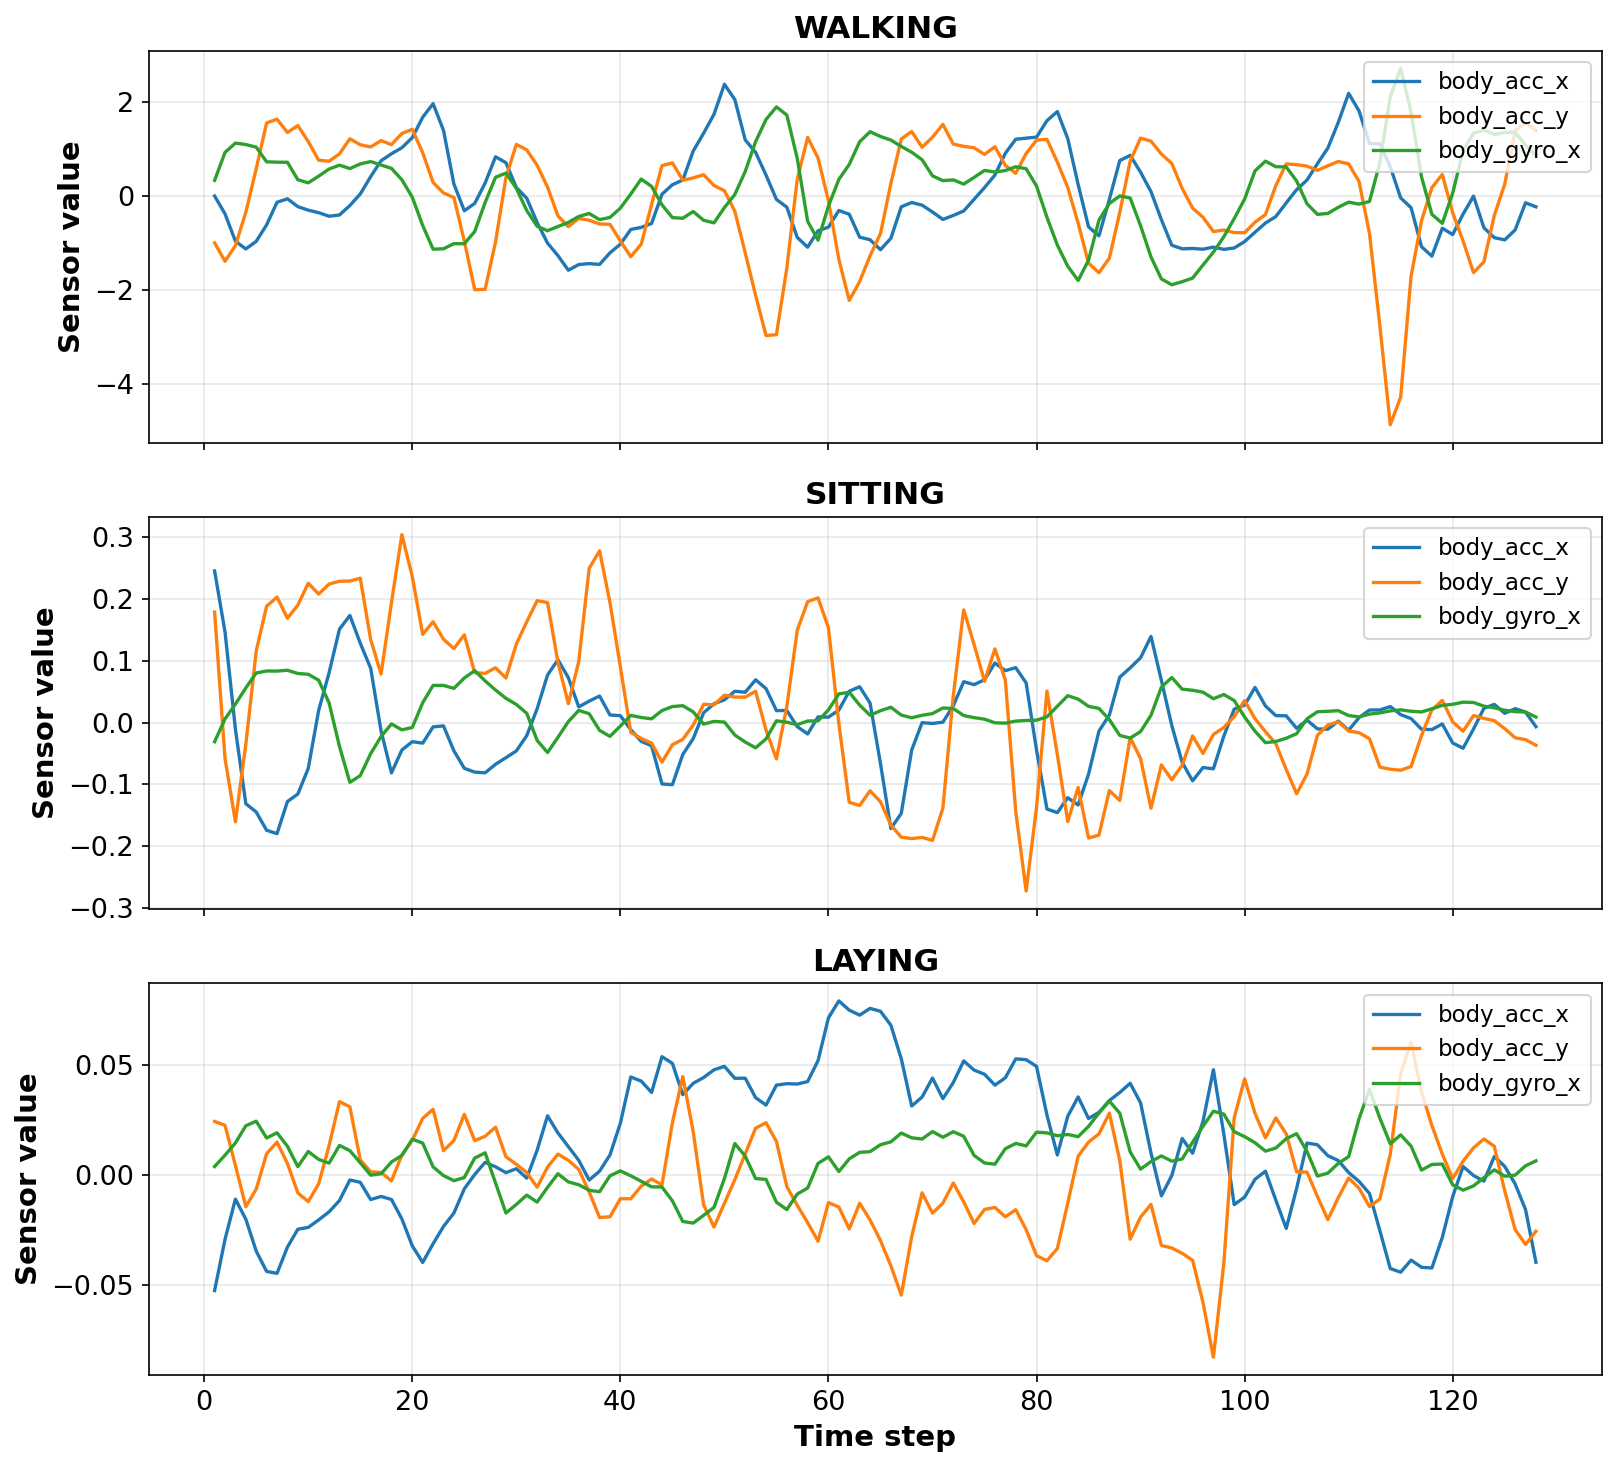

In [10]:
CHANNELS_TO_PLOT = ['body_acc_x', 'body_acc_y', 'body_gyro_x']
CHANNEL_IDX = {name: i for i, name in enumerate(SIGNAL_TYPES)}

example_classes = [0, 3, 5]  # WALKING, SITTING, LAYING (0-indexed) — distinct movement profiles
fig, axes = plt.subplots(len(example_classes), 1, figsize=(11, 10), sharex=True)

for ax, cls in zip(axes, example_classes):
    idx = np.where(y_train == cls)[0][0]
    sample = X_train[idx]
    for ch_name in CHANNELS_TO_PLOT:
        ax.plot(range(1, T+1), sample[:, CHANNEL_IDX[ch_name]], label=ch_name, linewidth=1.6)
    ax.set_title(f'{ACTIVITY_NAMES[cls+1]}')
    ax.set_ylabel('Sensor value')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time step')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot1_sensor_signals_vs_time.png'), bbox_inches='tight')
plt.show()


**Inference (Plot 1):**
- Walking shows high-frequency, high-amplitude oscillation across all plotted channels — consistent with repeated limb motion.
- Sitting and Laying show comparatively flat, low-variance traces since the body is static.
- Ordering of measurements matters because activity is defined by the temporal *pattern* (rate and repetition of oscillation), not by any single instantaneous reading — shuffling time steps would destroy the class signal even though the same 128 values are present.


---
## 8. Backpropagation Through Time — Numerical Exercise

Computing h1, h2, h3 directly from the given values (this is the answer, not a check against your own hand work — write the hand-derivation steps separately for the report).

⏱ **Estimated time: <1 min**


In [11]:
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

def rnn_step(x, h_prev, Wx, Wh, b):
    return np.tanh(Wx * x + Wh * h_prev + b)

h1 = rnn_step(x1, h0, Wx, Wh, b)
h2 = rnn_step(x2, h1, Wx, Wh, b)
h3 = rnn_step(x3, h2, Wx, Wh, b)

print(f"h1 = tanh({Wx}*{x1} + {Wh}*{h0} + {b}) = tanh({Wx*x1 + Wh*h0 + b:.4f}) = {h1:.6f}")
print(f"h2 = tanh({Wx}*{x2} + {Wh}*{h1:.6f} + {b}) = tanh({Wx*x2 + Wh*h1 + b:.4f}) = {h2:.6f}")
print(f"h3 = tanh({Wx}*{x3} + {Wh}*{h2:.6f} + {b}) = tanh({Wx*x3 + Wh*h2 + b:.4f}) = {h3:.6f}")


h1 = tanh(0.5*0.5 + 0.8*0.0 + 0.1) = tanh(0.3500) = 0.336376
h2 = tanh(0.5*0.7 + 0.8*0.336376 + 0.1) = tanh(0.7191) = 0.616352
h3 = tanh(0.5*0.2 + 0.8*0.616352 + 0.1) = tanh(0.6931) = 0.599958


---
## 7 & 9. Vanilla RNN — Architecture and Implementation

Architecture: `Input(128,9) -> SimpleRNN(32) -> Dropout(0.2) -> Dense(16, relu) -> Dense(6, softmax)`

⏱ **Estimated time: ~2–4 min** (30 epochs, small subset, GPU)


In [12]:
def build_rnn_model(recurrent_units=32, layer_type='SimpleRNN', bidirectional=False,
                     n_layers=1, input_shape=(128, 9), n_classes=6, seed=SEED):
    tf.random.set_seed(seed)
    layer_map = {'SimpleRNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}
    RecLayer = layer_map[layer_type]

    model = keras.Sequential(name=f'{layer_type}_u{recurrent_units}_l{n_layers}{"_bi" if bidirectional else ""}')
    model.add(layers.Input(shape=input_shape))

    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        rec = RecLayer(recurrent_units, return_sequences=return_seq)
        if bidirectional:
            rec = layers.Bidirectional(rec)
        model.add(rec)

    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(n_classes, activation='softmax'))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def train_and_time(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, verbose=0):
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - t0
    return history, elapsed

print("Helper functions defined.")


Helper functions defined.


In [13]:
print("Training Vanilla RNN...")
rnn_model = build_rnn_model(layer_type='SimpleRNN')
rnn_model.summary()
rnn_history, rnn_time = train_and_time(rnn_model, X_train, y_train, X_val, y_val, verbose=1)
print(f"RNN training time: {rnn_time:.1f}s")
rnn_model.save(os.path.join(MODELS_DIR, 'rnn_model.keras'))


Training Vanilla RNN...


I0000 00:00:1790132879.056198      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790132879.059445      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SimpleRNN_u32_l1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
19/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1975 - loss: 1.8536

I0000 00:00:1790132884.862830      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.3310 - loss: 1.6405 - val_accuracy: 0.4750 - val_loss: 1.4334
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4607 - loss: 1.3525 - val_accuracy: 0.5028 - val_loss: 1.2131
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5351 - loss: 1.1584 - val_accuracy: 0.5806 - val_loss: 1.0683
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5869 - loss: 1.0353 - val_accuracy: 0.6083 - val_loss: 0.9514
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6077 - loss: 0.9179 - val_accuracy: 0.6000 - val_loss: 0.9144
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6411 - loss: 0.8487 - val_accuracy: 0.6611 - val_loss: 0.8073
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6494 - loss: 0.7787 - val_accuracy: 0.6361 - val_loss: 0.7919
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6619 - loss: 0.7476 - val_accuracy: 0.6528 - val_loss: 0.

---
## 10 & 12. LSTM — Architecture and Implementation

Same classifier head, recurrent layer replaced with LSTM(32).

⏱ **Estimated time: ~2–4 min**


In [14]:
print("Training LSTM...")
lstm_model = build_rnn_model(layer_type='LSTM')
lstm_model.summary()
lstm_history, lstm_time = train_and_time(lstm_model, X_train, y_train, X_val, y_val, verbose=1)
print(f"LSTM training time: {lstm_time:.1f}s")
lstm_model.save(os.path.join(MODELS_DIR, 'lstm_model.keras'))


Training LSTM...


Model: "LSTM_u32_l1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3202 - loss: 1.6202 - val_accuracy: 0.3944 - val_loss: 1.4436
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4792 - loss: 1.3403 - val_accuracy: 0.5667 - val_loss: 1.1955
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6036 - loss: 1.0040 - val_accuracy: 0.5917 - val_loss: 0.8852
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6577 - loss: 0.7896 - val_accuracy: 0.7111 - val_loss: 0.7156
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7298 - loss: 0.6531 - val_accuracy: 0.7861 - val_loss: 0.5809
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7708 - loss: 0.5370 - val_accuracy: 0.7750 - val_loss: 0.5273
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7929 - loss: 0.4858 - val_accuracy: 0.8167 - val_loss: 0.4914
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7976 - loss: 0.5019 - val_accuracy: 0.8583 - v

---
## 11 & 12. GRU — Architecture and Implementation

Same classifier head, recurrent layer replaced with GRU(32).

⏱ **Estimated time: ~2–4 min**


In [15]:
print("Training GRU...")
gru_model = build_rnn_model(layer_type='GRU')
gru_model.summary()
gru_history, gru_time = train_and_time(gru_model, X_train, y_train, X_val, y_val, verbose=1)
print(f"GRU training time: {gru_time:.1f}s")
gru_model.save(os.path.join(MODELS_DIR, 'gru_model.keras'))

mark_block_done('core_models')


Training GRU...


Model: "GRU_u32_l1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3018 - loss: 1.5380 - val_accuracy: 0.3667 - val_loss: 1.3991
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3768 - loss: 1.3500 - val_accuracy: 0.4528 - val_loss: 1.2670
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4804 - loss: 1.1987 - val_accuracy: 0.5167 - val_loss: 1.1237
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5827 - loss: 1.0437 - val_accuracy: 0.6500 - val_loss: 0.9719
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6619 - loss: 0.8371 - val_accuracy: 0.6917 - val_loss: 0.7736
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7018 - loss: 0.6850 - val_accuracy: 0.7278 - val_loss: 0.6948
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7530 - loss: 0.6051 - val_accuracy: 0.7472 - val_loss: 0.6120
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8012 - loss: 0.5291 - val_accuracy: 0.7889 - v

---
## 13. Training and Validation Plots (Plot 2 & Plot 3)

Loss and accuracy curves for each of RNN, LSTM, GRU.

⏱ **Estimated time: <1 min**


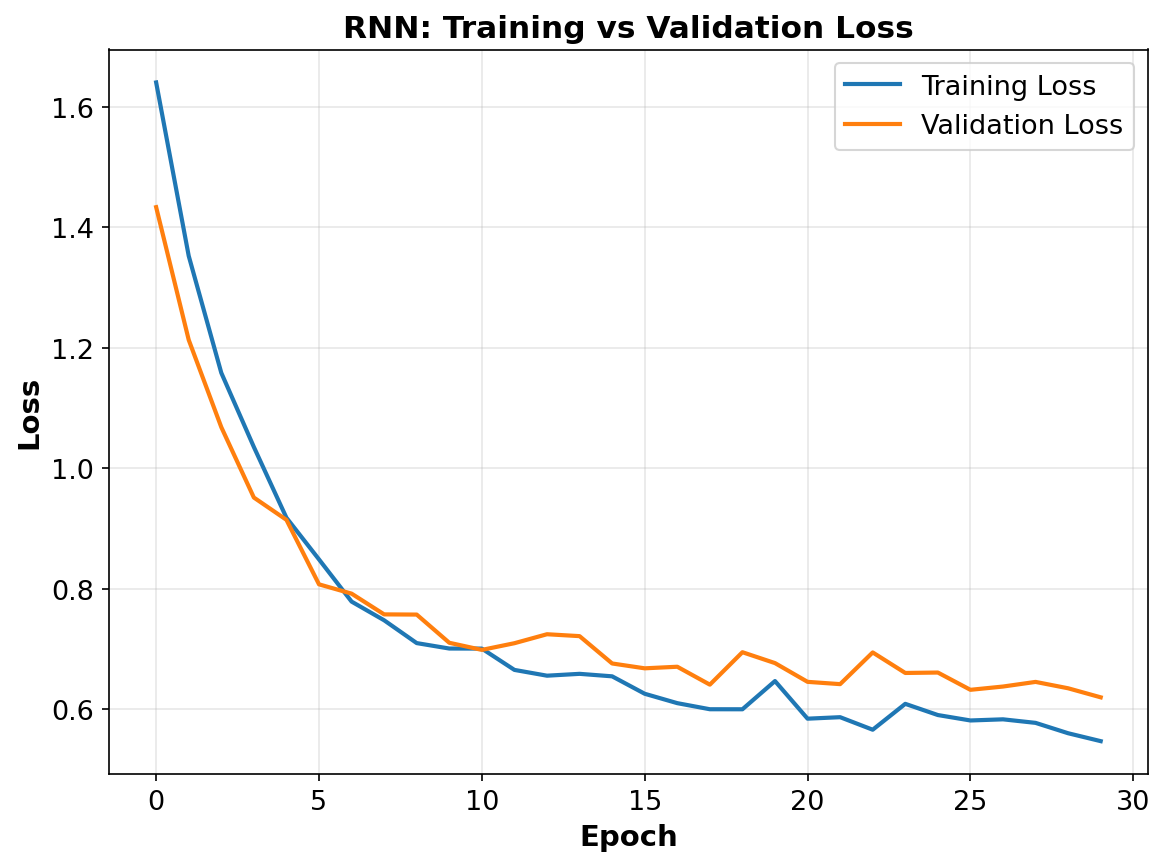

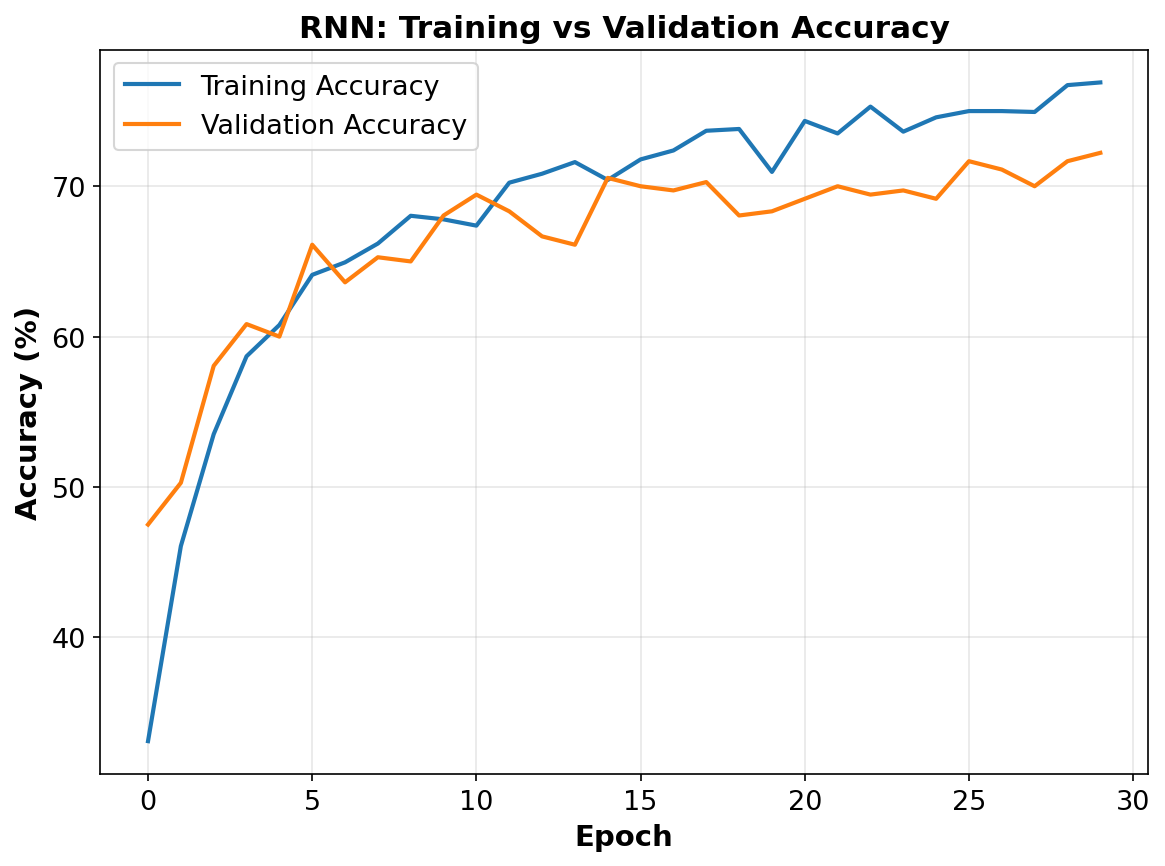

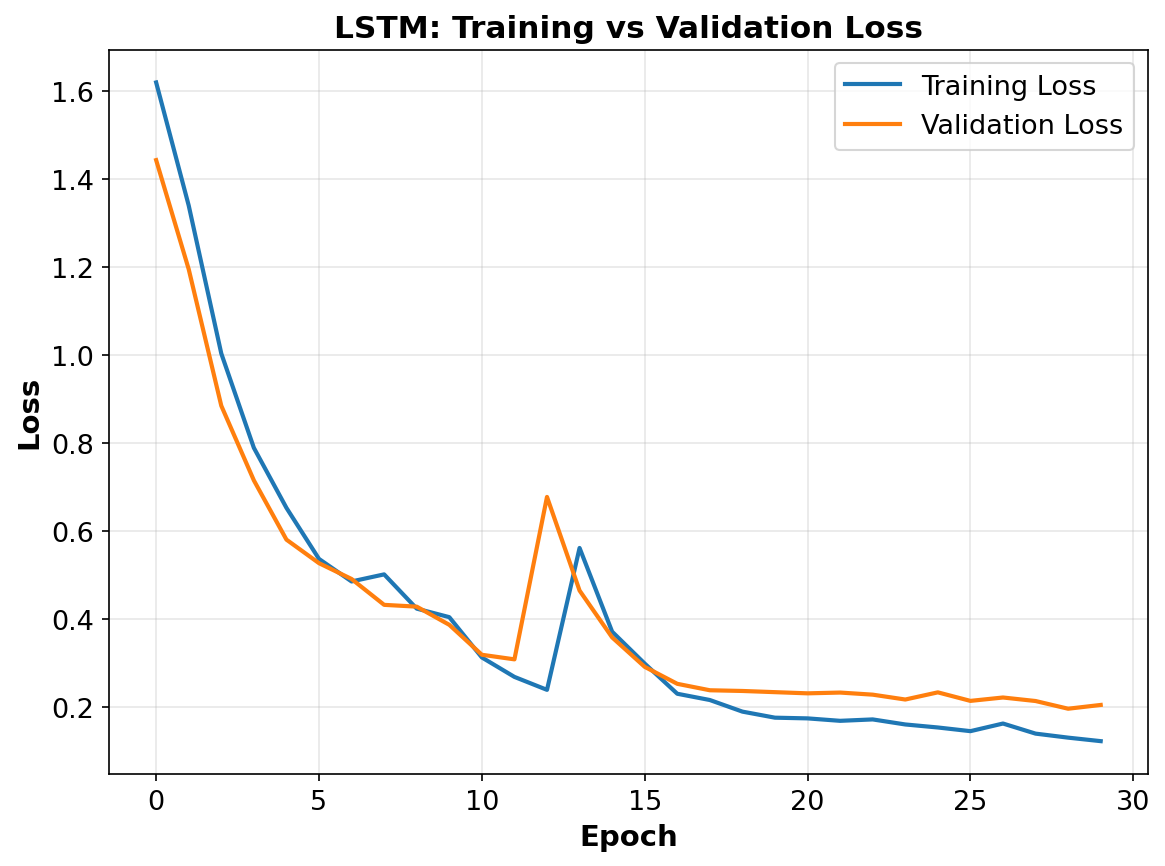

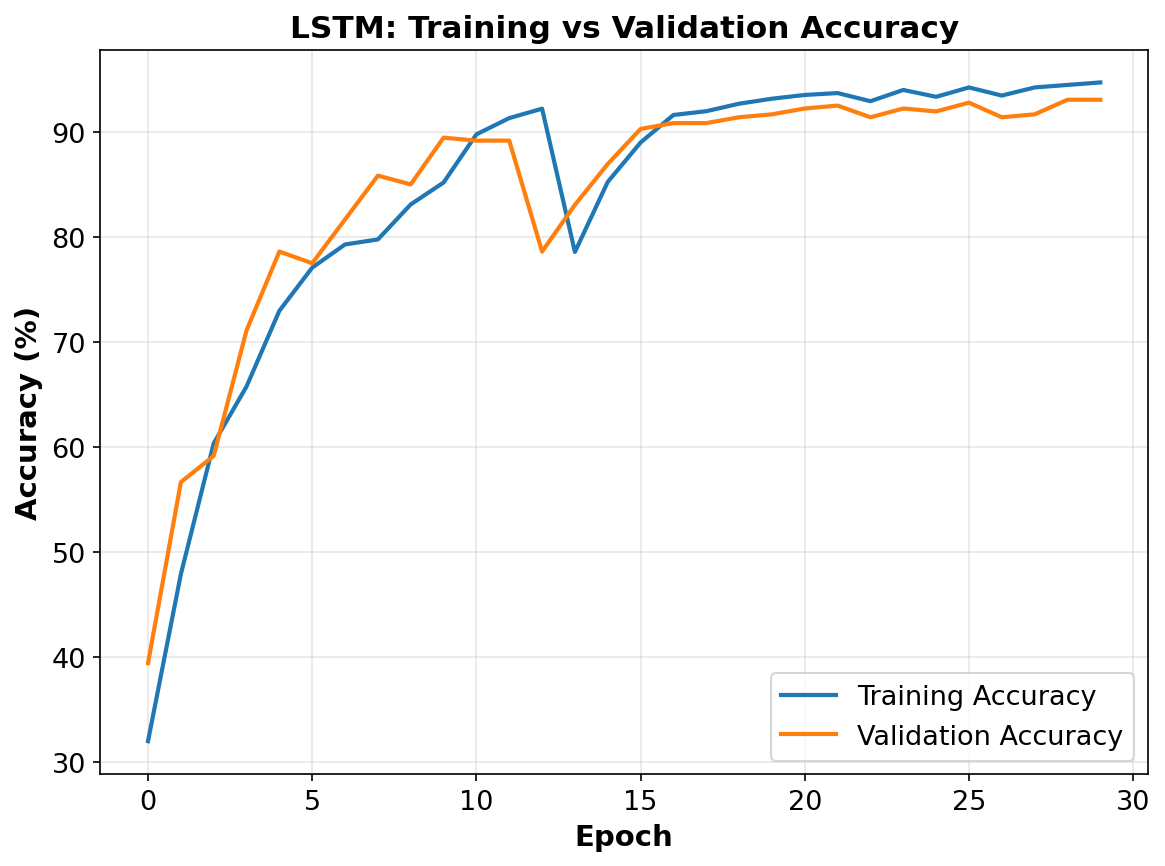

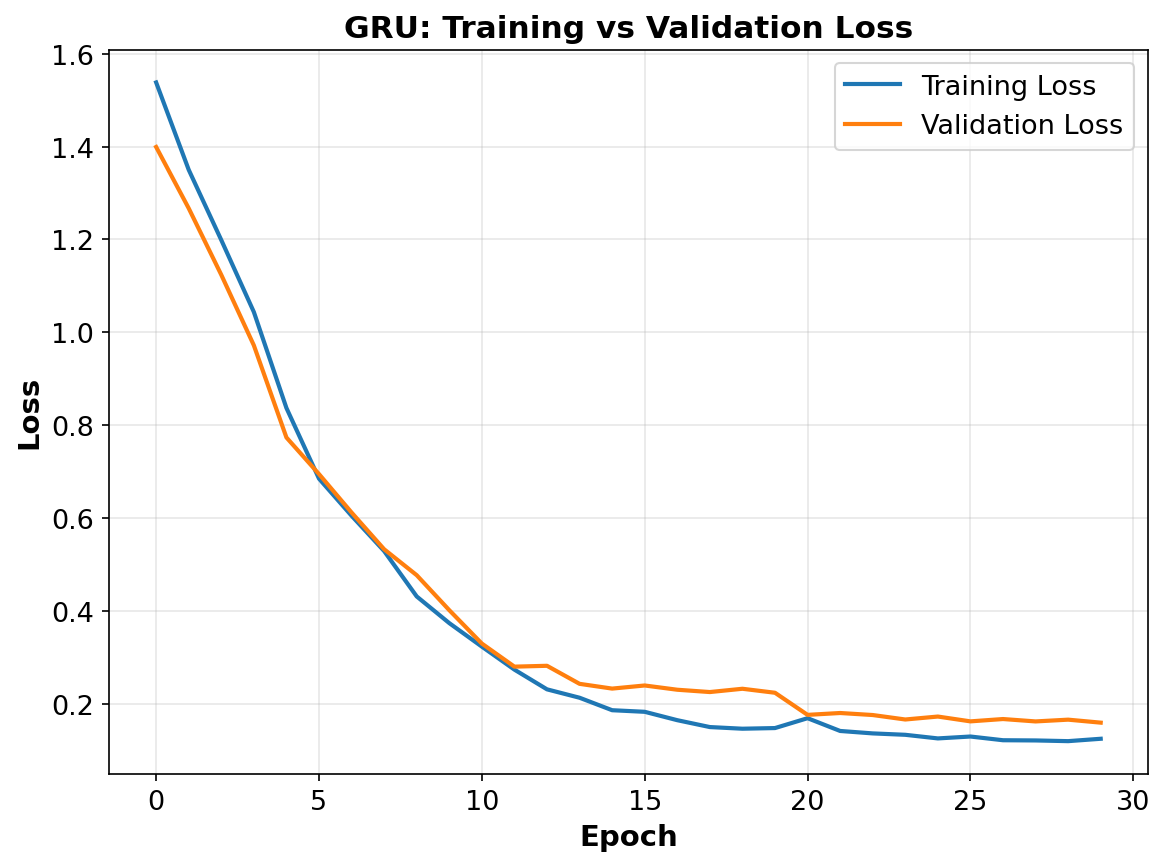

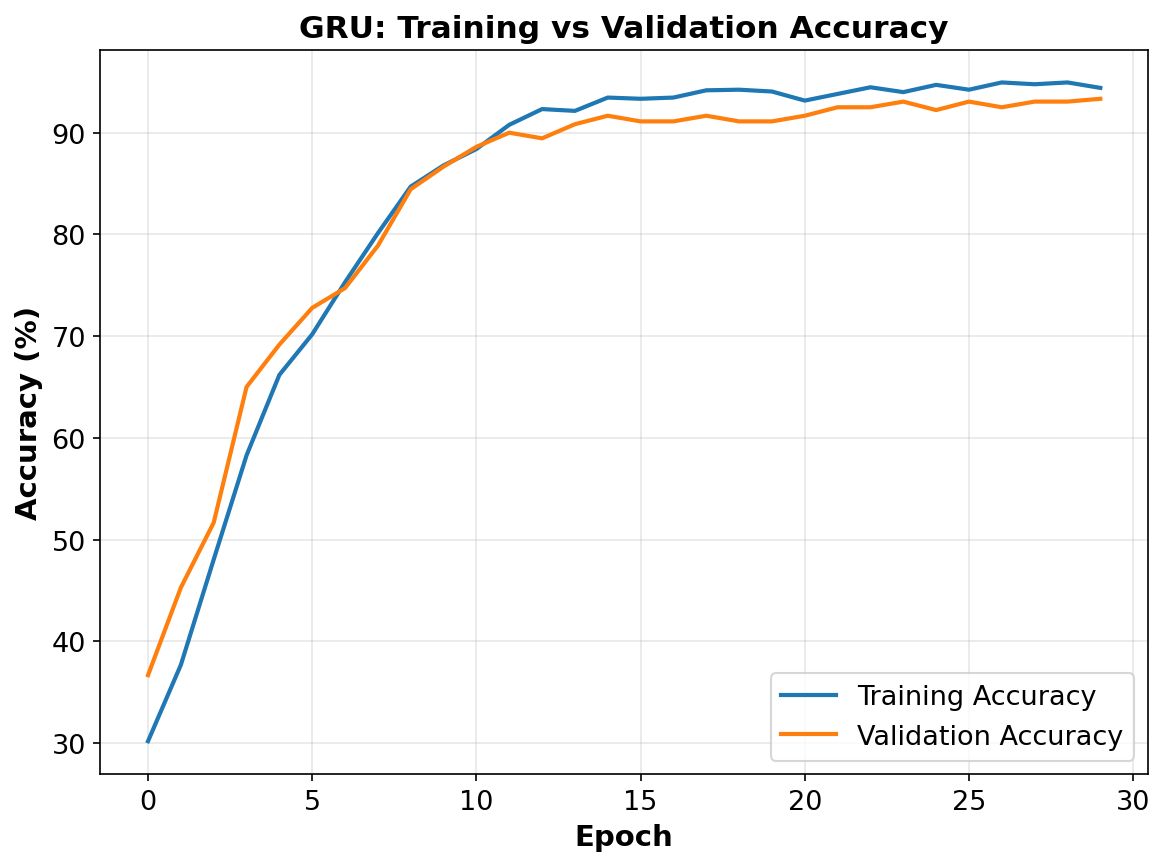

In [16]:
def plot_history(history, model_name, plots_dir=PLOTS_DIR):
    h = history.history

    # Plot 2: Loss
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(h['loss'], label='Training Loss', linewidth=2)
    ax.plot(h['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name}: Training vs Validation Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f'plot2_{model_name.lower()}_loss.png'), bbox_inches='tight')
    plt.show()

    # Plot 3: Accuracy
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(np.array(h['accuracy'])*100, label='Training Accuracy', linewidth=2)
    ax.plot(np.array(h['val_accuracy'])*100, label='Validation Accuracy', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{model_name}: Training vs Validation Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f'plot3_{model_name.lower()}_accuracy.png'), bbox_inches='tight')
    plt.show()

plot_history(rnn_history, 'RNN')
plot_history(lstm_history, 'LSTM')
plot_history(gru_history, 'GRU')


**Inference (Plots 2 & 3 — convergence):**
- *RNN*: [Fill in after running — describe whether loss decreases steadily or plateaus/oscillates, and whether val loss diverges from train loss (overfitting sign).]
- *LSTM*: [Fill in after running — typically smoother convergence than vanilla RNN due to gated memory.]
- *GRU*: [Fill in after running — compare convergence speed to LSTM.]

*(These will be filled in with your actual observed curves — not written in advance, since the manual requires inference based on your own results.)*


---
## 14. Performance Evaluation on Test Set

Accuracy, macro Precision/Recall/F1, confusion matrix, parameter count, training time — for each model.

⏱ **Estimated time: <1 min**


In [17]:
def evaluate_model(model, X_te, y_te, model_name, train_time):
    y_pred_probs = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_te, y_pred) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='macro', zero_division=0)
    n_params = model.count_params()

    print(f"--- {model_name} ---")
    print(f"Accuracy       : {acc:.2f}%")
    print(f"Macro Precision: {prec*100:.2f}%")
    print(f"Macro Recall   : {rec*100:.2f}%")
    print(f"Macro F1       : {f1*100:.2f}%")
    print(f"Parameters     : {n_params}")
    print(f"Training time  : {train_time:.1f}s")
    print(classification_report(y_te, y_pred, target_names=list(ACTIVITY_NAMES.values()), zero_division=0))

    return {'model': model_name, 'accuracy': acc, 'precision': prec*100, 'recall': rec*100,
            'f1': f1*100, 'params': n_params, 'train_time': train_time, 'y_pred': y_pred}

results_rnn = evaluate_model(rnn_model, X_test, y_test, 'RNN', rnn_time)
results_lstm = evaluate_model(lstm_model, X_test, y_test, 'LSTM', lstm_time)
results_gru = evaluate_model(gru_model, X_test, y_test, 'GRU', gru_time)

results_table = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [results_rnn, results_lstm, results_gru]
])
results_table


--- RNN ---
Accuracy       : 75.00%
Macro Precision: 75.70%
Macro Recall   : 75.00%
Macro F1       : 74.97%
Parameters     : 1974
Training time  : 24.2s
                    precision    recall  f1-score   support

           WALKING       0.62      0.55      0.58        60
  WALKING_UPSTAIRS       0.58      0.75      0.66        60
WALKING_DOWNSTAIRS       0.79      0.63      0.70        60
           SITTING       0.79      0.75      0.77        60
          STANDING       0.75      0.82      0.78        60
            LAYING       1.00      1.00      1.00        60

          accuracy                           0.75       360
         macro avg       0.76      0.75      0.75       360
      weighted avg       0.76      0.75      0.75       360

--- LSTM ---
Accuracy       : 93.06%
Macro Precision: 93.15%
Macro Recall   : 93.06%
Macro F1       : 93.02%
Parameters     : 6006
Training time  : 20.8s
                    precision    recall  f1-score   support

           WALKING       0.94

,model,accuracy,precision,recall,f1,params,train_time
0,RNN,75.000000,75.700727,75.000000,74.965660,1974,24.23406
1,LSTM,93.055556,93.149680,93.055556,93.022443,6006,20.77459
2,GRU,92.777778,92.788901,92.777778,92.775925,4758,17.99531


---
## 15. Confusion Matrix Analysis (Plot 4)

Separate confusion matrix per model.

⏱ **Estimated time: <1 min**


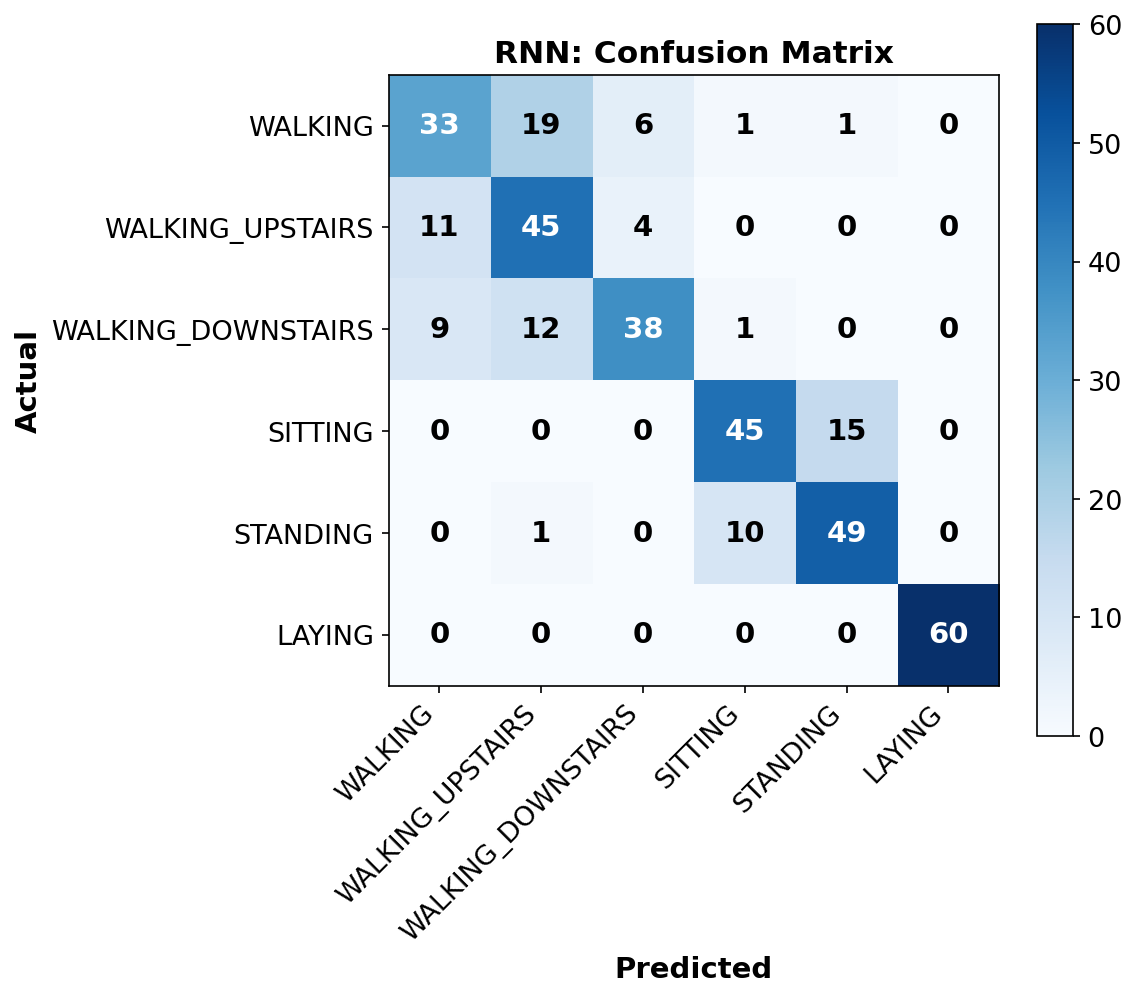

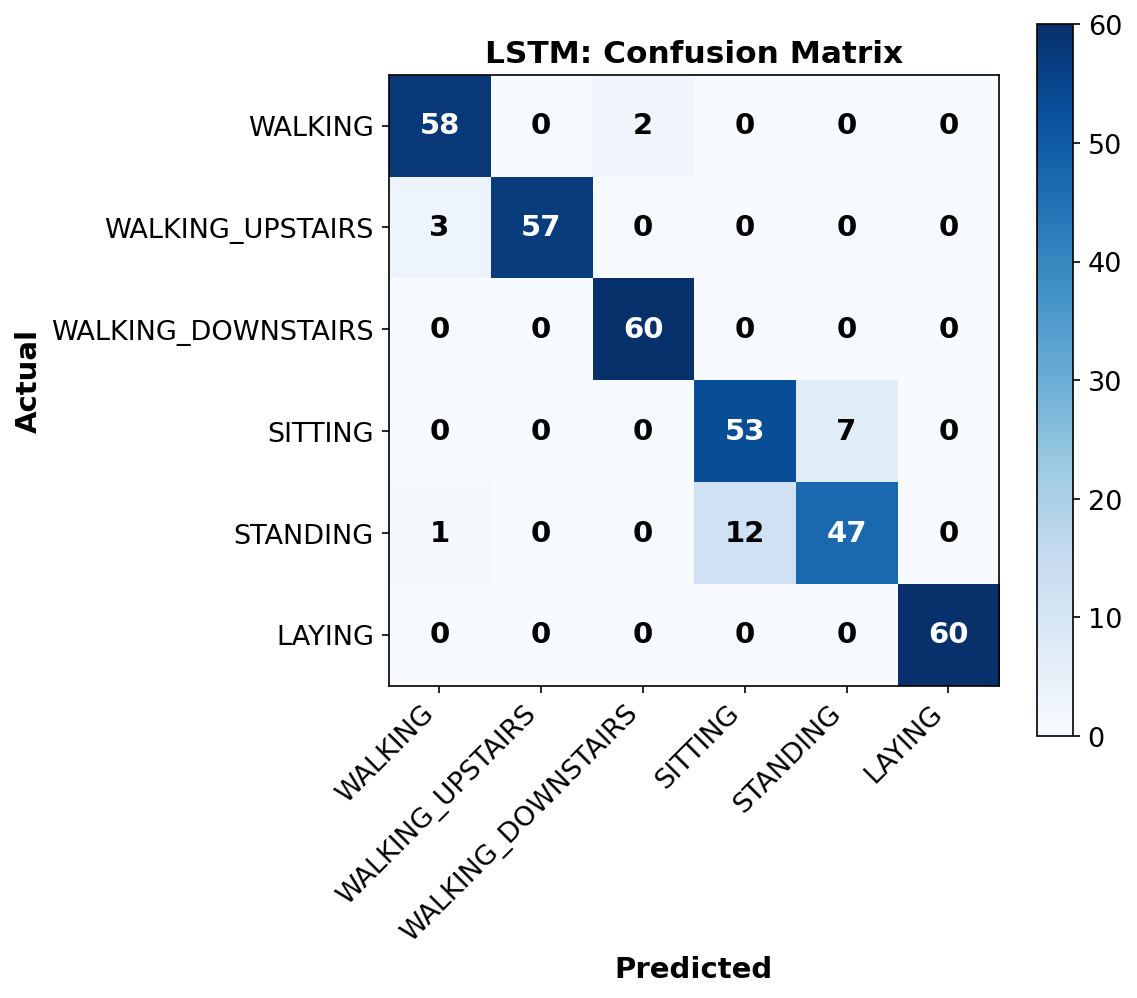

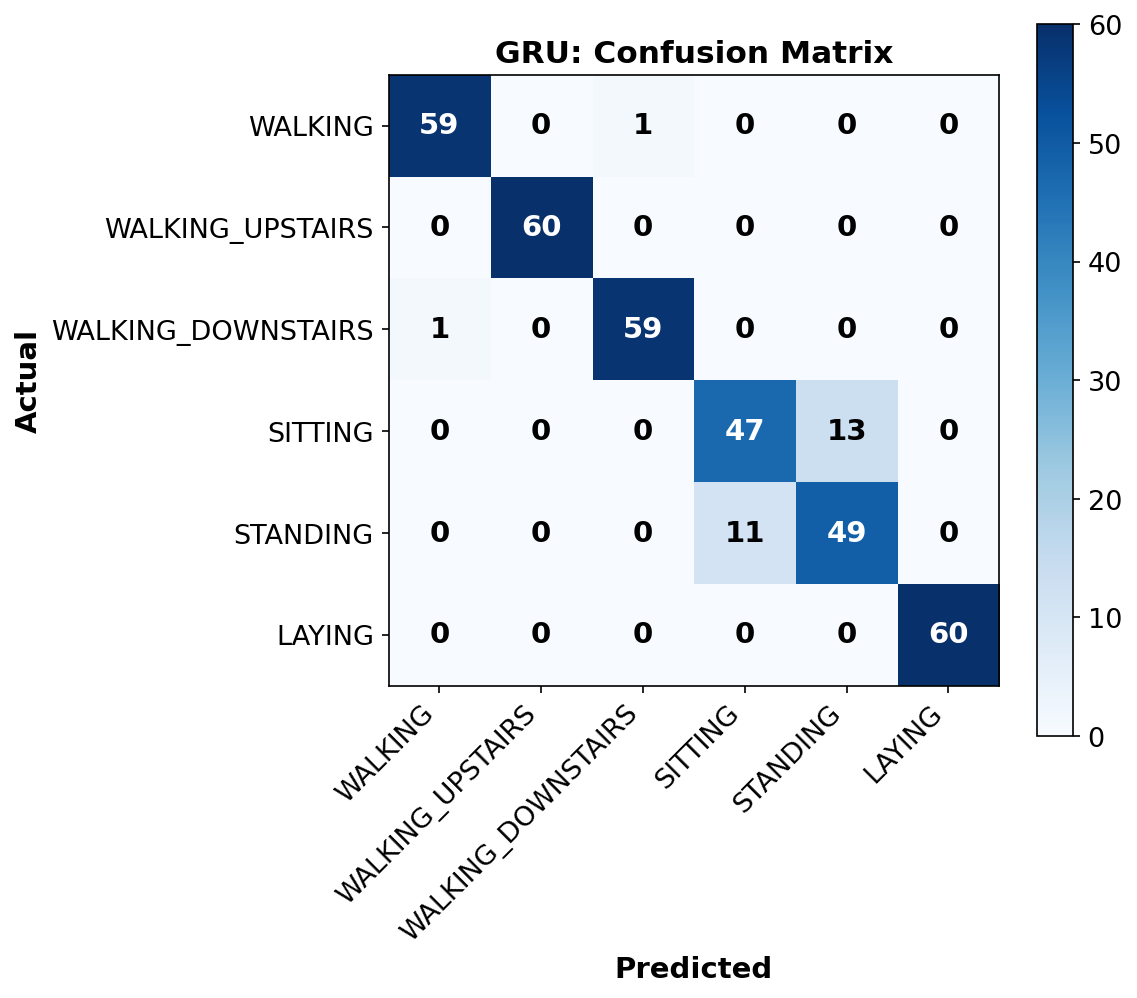

In [18]:
def plot_confusion(y_true, y_pred, model_name, plots_dir=PLOTS_DIR):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    labels = list(ACTIVITY_NAMES.values())
    ax.set_xticks(range(6)); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(6)); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}: Confusion Matrix')
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontweight='bold')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f'plot4_{model_name.lower()}_confusion.png'), bbox_inches='tight')
    plt.show()
    return cm

cm_rnn = plot_confusion(y_test, results_rnn['y_pred'], 'RNN')
cm_lstm = plot_confusion(y_test, results_lstm['y_pred'], 'LSTM')
cm_gru = plot_confusion(y_test, results_gru['y_pred'], 'GRU')

mark_block_done('evaluation')


**Inference (Plot 4 — confusion matrices):**
[Fill in after running: identify highest-recognition-rate activity, most-confused pair (commonly SITTING vs STANDING in HAR due to similar static sensor signatures), and whether error patterns are consistent across the three models.]


---
## 16. RNN vs LSTM vs GRU — Comparison (Plot 5)

⏱ **Estimated time: <1 min**


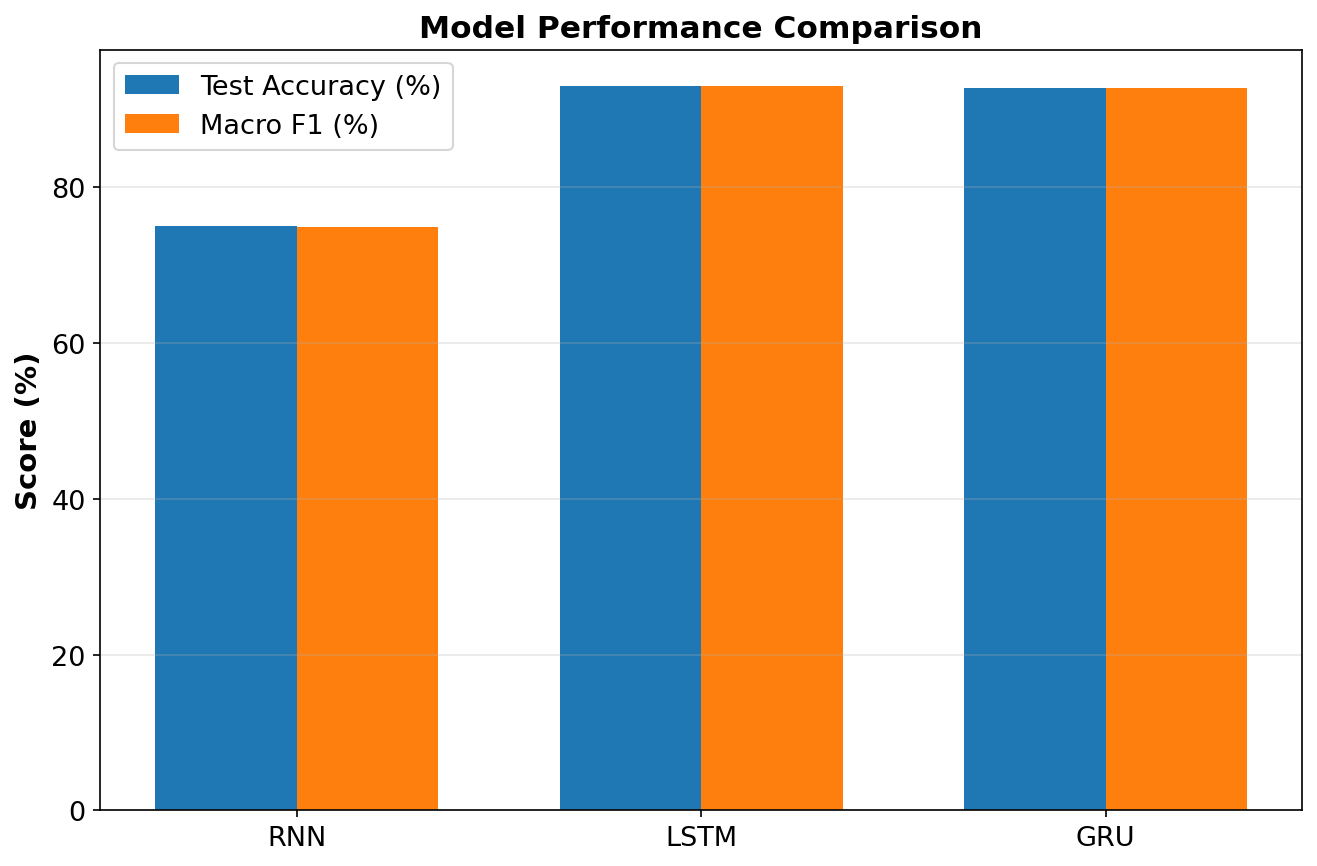

  model   accuracy  precision     recall         f1  params  train_time
0   RNN  75.000000  75.700727  75.000000  74.965660    1974    24.23406
1  LSTM  93.055556  93.149680  93.055556  93.022443    6006    20.77459
2   GRU  92.777778  92.788901  92.777778  92.775925    4758    17.99531


In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
metrics_to_plot = ['accuracy', 'f1']
x = np.arange(len(results_table))
width = 0.35

ax.bar(x - width/2, results_table['accuracy'], width, label='Test Accuracy (%)')
ax.bar(x + width/2, results_table['f1'], width, label='Macro F1 (%)')
ax.set_xticks(x)
ax.set_xticklabels(results_table['model'])
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot5_model_comparison.png'), bbox_inches='tight')
plt.show()

print(results_table)


**Required inference (Predictive Performance vs Complexity vs Cost):**
[Fill in after running: compare param counts and training times from the table above against accuracy/F1 — typically LSTM has the most parameters (4 gate-weight sets) and GRU is a middle ground (3 gate-weight sets) with RNN having the fewest but weakest long-range performance.]


---
## 17. Effect of Sequence Length (Plot 6)

Repeating the experiment with truncated sequence lengths T ∈ {32, 64, 128}. Truncation takes the first T timesteps of each window.

⏱ **Estimated time: ~20–25 min total** (9 more training runs: 3 models × 2 additional lengths, since T=128 is already done above)


In [20]:
def truncate_seq(X, T_new):
    return X[:, :T_new, :]

seq_lengths = [32, 64, 128]
seqlen_results = {}

# T=128 already trained above — reuse those results
seqlen_results[128] = {'RNN': results_rnn['f1'], 'LSTM': results_lstm['f1'], 'GRU': results_gru['f1']}

for T_new in [32, 64]:
    print(f"\n=== Sequence length T={T_new} ===")
    Xtr_t = truncate_seq(X_train, T_new)
    Xv_t = truncate_seq(X_val, T_new)
    Xte_t = truncate_seq(X_test, T_new)

    seqlen_results[T_new] = {}
    for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
        model = build_rnn_model(layer_type=layer_type, input_shape=(T_new, F))
        hist, elapsed = train_and_time(model, Xtr_t, y_train, Xv_t, y_val, verbose=0)
        y_pred = np.argmax(model.predict(Xte_t, verbose=0), axis=1)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
        key = 'RNN' if layer_type == 'SimpleRNN' else layer_type
        seqlen_results[T_new][key] = f1 * 100
        print(f"  {key} (T={T_new}): F1={f1*100:.2f}%, time={elapsed:.1f}s")

mark_block_done('seqlen_ablation')



=== Sequence length T=32 ===
  RNN (T=32): F1=79.43%, time=15.7s
  LSTM (T=32): F1=91.05%, time=14.4s
  GRU (T=32): F1=91.89%, time=14.2s

=== Sequence length T=64 ===
  RNN (T=64): F1=67.18%, time=17.4s
  LSTM (T=64): F1=93.59%, time=16.2s
  GRU (T=64): F1=92.50%, time=15.4s


                       RNN       LSTM        GRU
Sequence Length                                 
128              74.965660  93.022443  92.775925
32               79.425171  91.052207  91.894433
64               67.181233  93.591559  92.500443


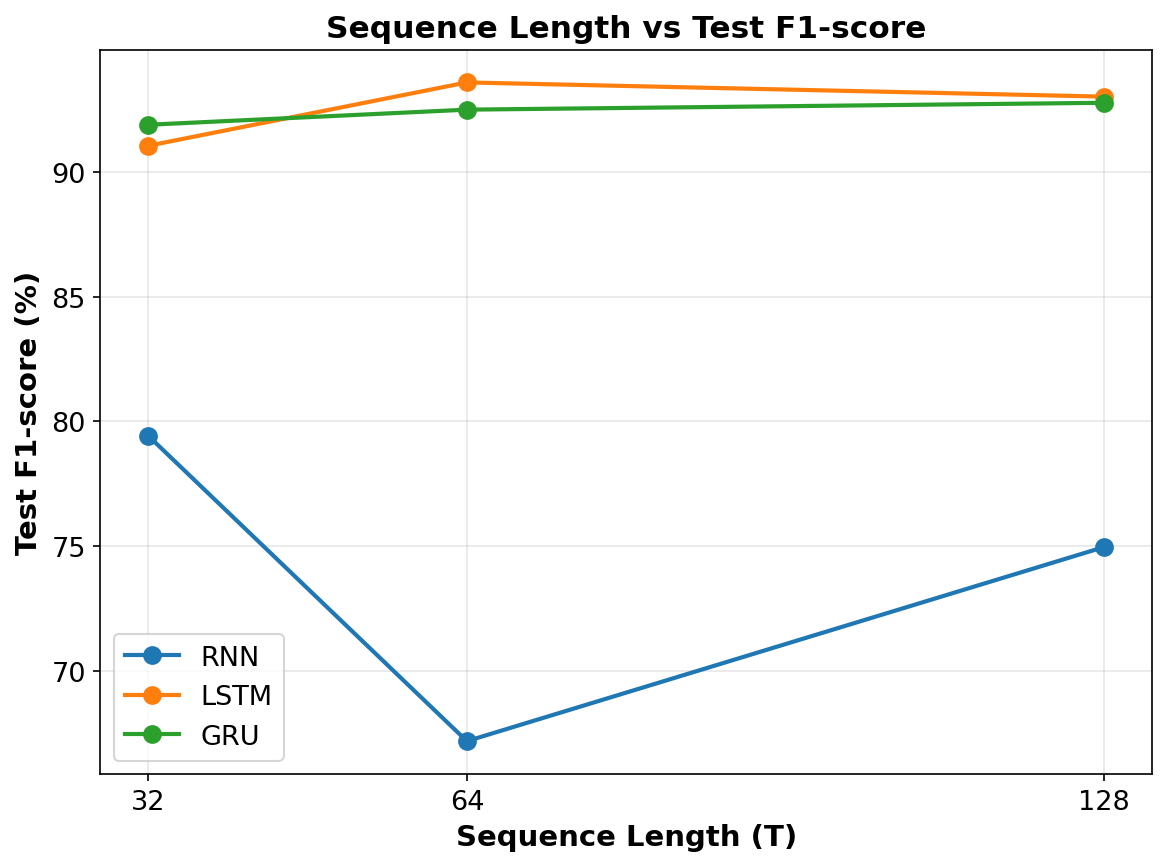

In [21]:
seqlen_df = pd.DataFrame(seqlen_results).T
seqlen_df.index.name = 'Sequence Length'
print(seqlen_df)

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in ['RNN', 'LSTM', 'GRU']:
    ax.plot(seq_lengths, [seqlen_results[T][model_name] for T in seq_lengths],
            marker='o', linewidth=2, markersize=8, label=model_name)
ax.set_xlabel('Sequence Length (T)')
ax.set_ylabel('Test F1-score (%)')
ax.set_title('Sequence Length vs Test F1-score')
ax.set_xticks(seq_lengths)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot6_seqlen_vs_f1.png'), bbox_inches='tight')
plt.show()


**Inference (Plot 6 — effect of sequence length):**
[Fill in after running: shorter sequences generally provide less temporal context, typically reducing F1 for activities that need more of the cycle to disambiguate (e.g. WALKING_UPSTAIRS vs WALKING_DOWNSTAIRS); check whether this holds in your results.]


---
## Checkpoint — HAR Core Pipeline Complete

Zips plots generated so far before moving to additional exercises, video, and seq2seq blocks.


In [22]:
zip_plots('exp6_checkpoint1_core_har_plots.zip')
print("Checkpoint 1 complete: preprocessing, visualization, RNN/LSTM/GRU, evaluation, seq-length ablation.")


Plots zipped to: /kaggle/working/exp6/exp6_checkpoint1_core_har_plots.zip
Checkpoint 1 complete: preprocessing, visualization, RNN/LSTM/GRU, evaluation, seq-length ablation.


---
# 28. Additional Exercises

⏱ **Estimated total for this section: ~25–35 min**


## 28.1 Unit Count Variants (16 and 64 units)

Repeat RNN/LSTM/GRU with 16 and 64 recurrent units (in addition to the 32 used above), comparing accuracy, F1, parameter count and training time.

⏱ **Estimated time: ~15–20 min** (6 more training runs)


In [23]:
unit_variant_results = []
for units in [16, 64]:
    for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
        model_name = 'RNN' if layer_type == 'SimpleRNN' else layer_type
        print(f"Training {model_name} with {units} units...")
        model = build_rnn_model(recurrent_units=units, layer_type=layer_type)
        hist, elapsed = train_and_time(model, X_train, y_train, X_val, y_val, verbose=0)
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred) * 100
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
        unit_variant_results.append({
            'model': model_name, 'units': units, 'accuracy': acc, 'f1': f1*100,
            'params': model.count_params(), 'train_time': elapsed
        })
        print(f"  Accuracy={acc:.2f}%, F1={f1*100:.2f}%, params={model.count_params()}, time={elapsed:.1f}s")

unit_variant_df = pd.DataFrame(unit_variant_results)
print(unit_variant_df)


Training RNN with 16 units...
  Accuracy=75.00%, F1=74.80%, params=790, time=22.6s
Training LSTM with 16 units...
  Accuracy=89.44%, F1=89.38%, params=2038, time=17.8s
Training GRU with 16 units...
  Accuracy=92.78%, F1=92.78%, params=1670, time=17.6s
Training RNN with 64 units...
  Accuracy=72.50%, F1=72.33%, params=5878, time=23.3s
Training LSTM with 64 units...
  Accuracy=93.06%, F1=93.00%, params=20086, time=17.8s
Training GRU with 64 units...
  Accuracy=93.06%, F1=93.05%, params=15542, time=17.5s
  model  units   accuracy         f1  params  train_time
0   RNN     16  75.000000  74.800698     790   22.557783
1  LSTM     16  89.444444  89.381477    2038   17.801242
2   GRU     16  92.777778  92.777276    1670   17.589817
3   RNN     64  72.500000  72.331475    5878   23.349566
4  LSTM     64  93.055556  93.002616   20086   17.778372
5   GRU     64  93.055556  93.053684   15542   17.509330


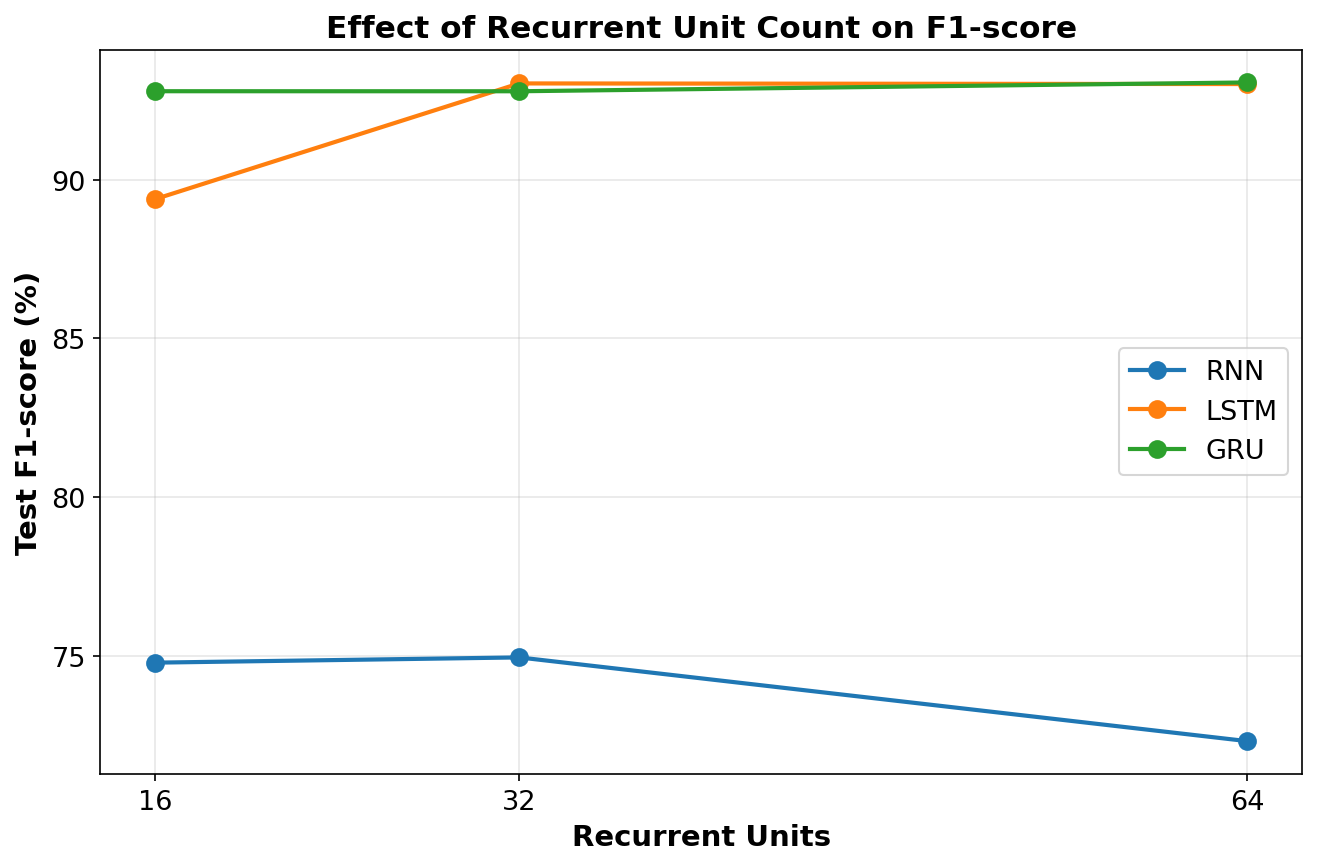

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
for model_name in ['RNN', 'LSTM', 'GRU']:
    sub = unit_variant_df[unit_variant_df['model'] == model_name].sort_values('units')
    all_units = [16, 32, 64]
    all_f1 = []
    for u in all_units:
        if u == 32:
            base_f1 = {'RNN': results_rnn['f1'], 'LSTM': results_lstm['f1'], 'GRU': results_gru['f1']}[model_name]
            all_f1.append(base_f1)
        else:
            all_f1.append(sub[sub['units'] == u]['f1'].values[0])
    ax.plot(all_units, all_f1, marker='o', linewidth=2, markersize=8, label=model_name)
ax.set_xlabel('Recurrent Units')
ax.set_ylabel('Test F1-score (%)')
ax.set_title('Effect of Recurrent Unit Count on F1-score')
ax.set_xticks(all_units)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot_extra_units_vs_f1.png'), bbox_inches='tight')
plt.show()


**Inference (unit count variants):**
[Fill in after running: typically more units increase parameter count and training time with diminishing/no accuracy gains on this dataset size — check whether 64 units overfits given the subset size.]


## 28.2 Compare GRU and LSTM at Same Unit Count

Already directly comparable from the 28.1 results table (both trained at 16, 32, 64 units identically) — no additional training needed.

⏱ **Estimated time: <1 min**


In [25]:
compare_gru_lstm = unit_variant_df[unit_variant_df['model'].isin(['LSTM', 'GRU'])]
print(compare_gru_lstm.pivot(index='units', columns='model', values=['accuracy', 'f1', 'params', 'train_time']))


        accuracy                    f1              params           \
model        GRU       LSTM        GRU       LSTM      GRU     LSTM   
units                                                                 
16     92.777778  89.444444  92.777276  89.381477   1670.0   2038.0   
64     93.055556  93.055556  93.053684  93.002616  15542.0  20086.0   

      train_time             
model        GRU       LSTM  
units                        
16     17.589817  17.801242  
64     17.509330  17.778372  


**Inference (GRU vs LSTM, same units):**
[Fill in after running: GRU has fewer parameters than LSTM at every unit count (3 gates vs 4), so compare whether GRU achieves comparable F1 with less training time — this is GRU's typical selling point.]


## 28.3 Second Recurrent Layer

Stack two recurrent layers for RNN, LSTM, GRU (32 units each layer) and check whether depth improves performance.

⏱ **Estimated time: ~12–15 min** (3 training runs, 2-layer models are slower per epoch)


In [26]:
two_layer_results = []
for layer_type in ['SimpleRNN', 'LSTM', 'GRU']:
    model_name = 'RNN' if layer_type == 'SimpleRNN' else layer_type
    print(f"Training 2-layer {model_name}...")
    model = build_rnn_model(layer_type=layer_type, n_layers=2)
    hist, elapsed = train_and_time(model, X_train, y_train, X_val, y_val, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred) * 100
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    two_layer_results.append({'model': model_name, 'accuracy': acc, 'f1': f1*100,
                               'params': model.count_params(), 'train_time': elapsed})
    print(f"  Accuracy={acc:.2f}%, F1={f1*100:.2f}%, params={model.count_params()}, time={elapsed:.1f}s")

two_layer_df = pd.DataFrame(two_layer_results)
print(two_layer_df)


Training 2-layer RNN...
  Accuracy=80.56%, F1=79.78%, params=4054, time=36.4s
Training 2-layer LSTM...
  Accuracy=92.78%, F1=92.75%, params=14326, time=25.2s
Training 2-layer GRU...
  Accuracy=93.61%, F1=93.61%, params=11094, time=24.7s
  model   accuracy         f1  params  train_time
0   RNN  80.555556  79.784450    4054   36.405760
1  LSTM  92.777778  92.750910   14326   25.164453
2   GRU  93.611111  93.611092   11094   24.662572


**Inference (second recurrent layer):**
[Fill in after running: compare against the single-layer results from Section 16 — extra depth can help capture higher-level temporal abstractions but risks overfitting/vanishing gradients on a dataset this size; check which happened.]


## 28.4 Bidirectional vs Unidirectional LSTM

⏱ **Estimated time: ~8 min**


In [27]:
print("Training Bidirectional LSTM...")
bilstm_model = build_rnn_model(layer_type='LSTM', bidirectional=True)
bilstm_hist, bilstm_time = train_and_time(bilstm_model, X_train, y_train, X_val, y_val, verbose=0)
y_pred_bilstm = np.argmax(bilstm_model.predict(X_test, verbose=0), axis=1)
acc_bilstm = accuracy_score(y_test, y_pred_bilstm) * 100
_, _, f1_bilstm, _ = precision_recall_fscore_support(y_test, y_pred_bilstm, average='macro', zero_division=0)

print(f"Bidirectional LSTM: Accuracy={acc_bilstm:.2f}%, F1={f1_bilstm*100:.2f}%, "
      f"params={bilstm_model.count_params()}, time={bilstm_time:.1f}s")
print(f"(Compare against unidirectional LSTM from Section 12: "
      f"Accuracy={results_lstm['accuracy']:.2f}%, F1={results_lstm['f1']:.2f}%, "
      f"params={results_lstm['params']}, time={results_lstm['train_time']:.1f}s)")


Training Bidirectional LSTM...
Bidirectional LSTM: Accuracy=92.78%, F1=92.76%, params=11894, time=24.9s
(Compare against unidirectional LSTM from Section 12: Accuracy=93.06%, F1=93.02%, params=6006, time=20.8s)


**Inference (bidirectional vs unidirectional LSTM):**
[Fill in after running: bidirectional processes the sequence both forward and backward, roughly doubling parameters — check whether this improves F1 enough to justify the added cost for this dataset.]


In [28]:
mark_block_done('additional_exercises')
zip_plots('exp6_checkpoint2_additional_exercises_plots.zip')
print("Checkpoint 2 complete: Section 28 additional/optional exercises.")


Plots zipped to: /kaggle/working/exp6/exp6_checkpoint2_additional_exercises_plots.zip
Checkpoint 2 complete: Section 28 additional/optional exercises.


---
# 18–21. Video Understanding Using CNN and RNN

**Dataset:** UCF101 subset (Kaggle: `abdallahwagih/ucf101-videos`) -- a pre-curated 5-class subset, **not** the full 101-class UCF101. The 5 classes available in this dataset are: **CricketShot, PlayingCello, Punch, ShavingBeard, TennisSwing** -- using all 5, up to 10 videos per class (dataset provides at most a few dozen per class; we sample up to 10).

⏱ **Estimated time: 15–30 min total** (frame extraction + CNN feature extraction is the slow part; LSTM/GRU training on extracted features is fast)


## Kaggle Dataset Access

**Action needed before running this cell:** on the right sidebar of this Kaggle notebook, click **"Add Input"** → search for **`abdallahwagih/ucf101-videos`** → add it (skip if already attached). No API key/auth needed when running natively inside Kaggle -- attached datasets appear automatically under `/kaggle/input/`.


In [29]:
# Locate the attached dataset under /kaggle/input
import glob as glob_module

kaggle_input_candidates = (glob_module.glob('/kaggle/input/**/train.csv', recursive=True))
kaggle_input_candidates = [os.path.dirname(p) for p in kaggle_input_candidates if '__MACOSX' not in p]
assert len(kaggle_input_candidates) > 0, (
    "UCF101 dataset (with train.csv) not found under /kaggle/input. "
    "Add it via the 'Add Input' button in the right sidebar (search: abdallahwagih/ucf101-videos) "
    "then re-run this cell."
)
UCF101_INPUT_ROOT = kaggle_input_candidates[0]
print("Found UCF101 dataset at:", UCF101_INPUT_ROOT)
print("Contents:", os.listdir(UCF101_INPUT_ROOT))


Found UCF101 dataset at: /kaggle/input/datasets/abdallahwagih/ucf101-videos
Contents: ['train.csv', 'test.csv', 'test', 'train']


## Load Video Manifest and Select Classes

This dataset uses a CSV manifest (`video_name`, `tag`) mapping each video file to its class label, with videos stored flat under `train/` and `test/` folders -- not organized into per-class subfolders.

⏱ **Estimated time: <1 min**


In [30]:
VIDEO_DATA_DIR = UCF101_INPUT_ROOT  # read-only /kaggle/input mount
VIDEO_CACHE_DIR = os.path.join(BASE_DIR, 'video_cache')  # writable location for extracted frames/features
os.makedirs(VIDEO_CACHE_DIR, exist_ok=True)

train_manifest = pd.read_csv(os.path.join(VIDEO_DATA_DIR, 'train.csv'))
test_manifest = pd.read_csv(os.path.join(VIDEO_DATA_DIR, 'test.csv'))
full_manifest = pd.concat([
    train_manifest.assign(split_folder='train'),
    test_manifest.assign(split_folder='test')
], ignore_index=True)

print("Classes available in this dataset:", sorted(full_manifest['tag'].unique()))
print("Total videos in manifest:", len(full_manifest))

# All 5 classes present in this dataset are used directly (this is a pre-curated 5-class subset)
SELECTED_CLASSES = sorted(full_manifest['tag'].unique())
VIDEOS_PER_CLASS = 10

mark_block_done('video_download')
print("Using classes:", SELECTED_CLASSES)


Classes available in this dataset: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
Total videos in manifest: 818
Using classes: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']


In [31]:
# ---- Select up to 10 videos per class (fixed seed for reproducibility) ----
rng_video = np.random.RandomState(SEED)
selected_videos = {}

for cls in SELECTED_CLASSES:
    cls_rows = full_manifest[full_manifest['tag'] == cls]
    n_available = len(cls_rows)
    n_pick = min(VIDEOS_PER_CLASS, n_available)
    chosen_rows = cls_rows.sample(n=n_pick, random_state=SEED)

    video_paths = [
        os.path.join(VIDEO_DATA_DIR, row['split_folder'], row['video_name'])
        for _, row in chosen_rows.iterrows()
    ]
    # Keep only files that actually exist on disk
    video_paths = [p for p in video_paths if os.path.exists(p)]
    selected_videos[cls] = video_paths
    print(f"{cls}: selected {len(video_paths)} videos (out of {n_available} available)")

assert all(len(v) > 0 for v in selected_videos.values()), \
    "STOP: at least one class has zero valid video files -- check paths above."

mark_block_done('video_selection')


CricketShot: selected 10 videos (out of 167 available)
PlayingCello: selected 10 videos (out of 164 available)
Punch: selected 10 videos (out of 160 available)
ShavingBeard: selected 10 videos (out of 161 available)
TennisSwing: selected 10 videos (out of 166 available)


---
## 19. Video Frame Extraction

Sample 10 frames uniformly per video, resize to 224×224×3.

⏱ **Estimated time: 5–10 min**


In [32]:
get_ipython().system('pip install -q opencv-python-headless')
import cv2

N_FRAMES = 10
FRAME_SIZE = (224, 224)

def extract_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return None
    indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frames.append(np.zeros((*size, 3), dtype=np.uint8))
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frames.append(frame)
    cap.release()
    return np.array(frames)


In [33]:
if not block_done('frame_extraction'):
    video_labels = []
    all_frames_list = []

    for cls_idx, (cls, vids) in enumerate(selected_videos.items()):
        for vid_path in vids:
            frames = extract_frames(vid_path)
            if frames is not None:
                all_frames_list.append(frames)
                video_labels.append(cls_idx)

    all_frames_array = np.array(all_frames_list)
    video_labels = np.array(video_labels)

    np.save(os.path.join(VIDEO_CACHE_DIR, 'all_frames.npy'), all_frames_array)
    np.save(os.path.join(VIDEO_CACHE_DIR, 'video_labels.npy'), video_labels)
    mark_block_done('frame_extraction')
    print(f"Extracted frames for {len(all_frames_array)} videos. Shape: {all_frames_array.shape}")
else:
    all_frames_array = np.load(os.path.join(VIDEO_CACHE_DIR, 'all_frames.npy'))
    video_labels = np.load(os.path.join(VIDEO_CACHE_DIR, 'video_labels.npy'))
    print(f"Loaded cached frames. Shape: {all_frames_array.shape}")


Extracted frames for 50 videos. Shape: (50, 10, 224, 224, 3)


### Plot 7: Video Sample Frames

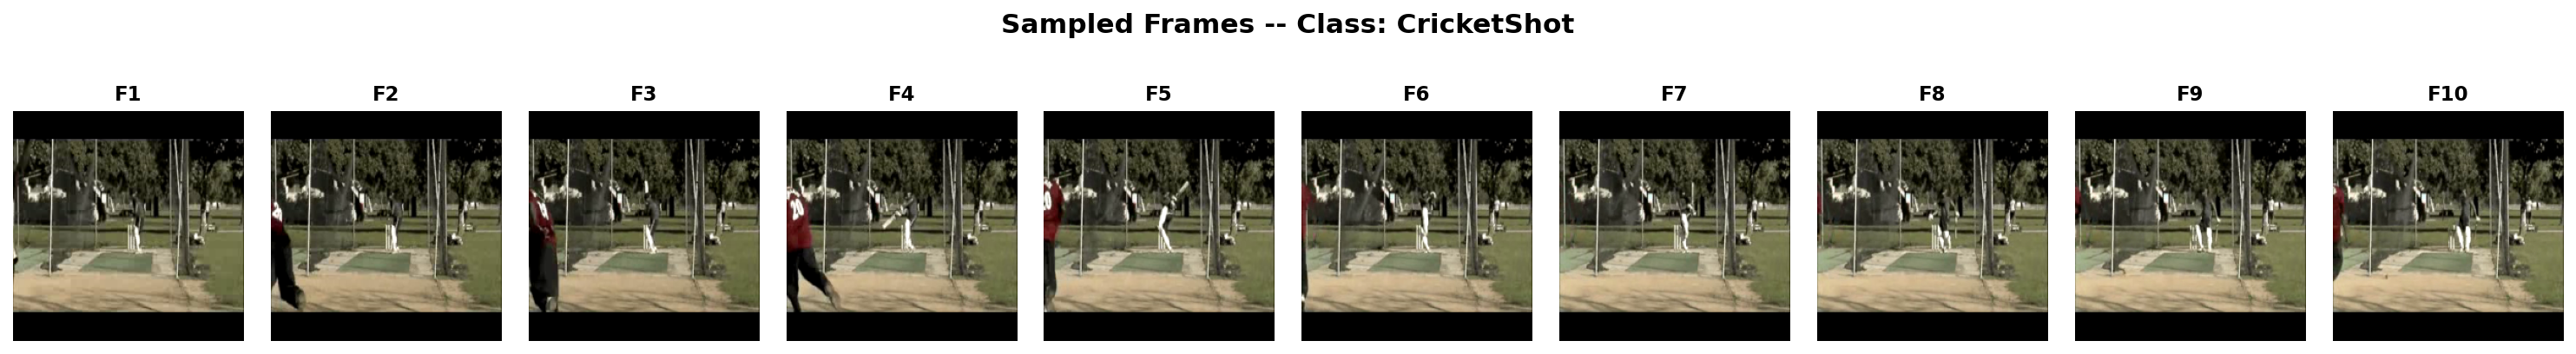

In [34]:
fig, axes = plt.subplots(1, N_FRAMES, figsize=(20, 3))
sample_video = all_frames_array[0]
for i, ax in enumerate(axes):
    ax.imshow(sample_video[i])
    ax.axis('off')
    ax.set_title(f'F{i+1}', fontsize=11)
plt.suptitle(f'Sampled Frames -- Class: {SELECTED_CLASSES[video_labels[0]]}', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot7_video_sample_frames.png'), bbox_inches='tight')
plt.show()


---
## 20. CNN Feature Extraction (MobileNetV2, frozen)

⏱ **Estimated time: 5–15 min**


In [35]:
if not block_done('cnn_features'):
    from tensorflow.keras.applications import MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    cnn_base = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    cnn_base.trainable = False

    n_videos, n_frames = all_frames_array.shape[:2]
    flat_frames = all_frames_array.reshape(-1, 224, 224, 3).astype('float32')
    flat_frames = preprocess_input(flat_frames)

    print("Extracting CNN features (this is the slow step)...")
    t0 = time.time()
    features_flat = cnn_base.predict(flat_frames, batch_size=32, verbose=1)
    print(f"CNN feature extraction took {time.time()-t0:.1f}s")

    D = features_flat.shape[-1]
    video_features = features_flat.reshape(n_videos, n_frames, D)

    np.save(os.path.join(VIDEO_CACHE_DIR, 'video_features.npy'), video_features)
    mark_block_done('cnn_features')
    print(f"CNN feature dimension D = {D}")
    print(f"Resulting tensor shape supplied to recurrent network: {video_features.shape}")
else:
    video_features = np.load(os.path.join(VIDEO_CACHE_DIR, 'video_features.npy'))
    D = video_features.shape[-1]
    print(f"Loaded cached features. Shape: {video_features.shape}, D={D}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting CNN features (this is the slow step)...


2026-09-23 03:15:17.078146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 03:15:17.215712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

2026-09-23 03:15:28.992535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 03:15:29.141680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 03:15:29.278339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 812ms/step
CNN feature extraction took 27.1s
CNN feature dimension D = 1280
Resulting tensor shape supplied to recurrent network: (50, 10, 1280)


---
## 21. CNN–LSTM / CNN–GRU Model

⏱ **Estimated time: ~5–8 min**


In [36]:
Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
    video_features, video_labels, test_size=0.30, stratify=video_labels, random_state=SEED)
Xv_val, Xv_test, yv_val, yv_test = train_test_split(
    Xv_temp, yv_temp, test_size=0.50, stratify=yv_temp, random_state=SEED)

print("Video train:", Xv_train.shape, "val:", Xv_val.shape, "test:", Xv_test.shape)

def build_video_model(layer_type='LSTM', units=32, seq_len=N_FRAMES, feat_dim=None, n_classes=5, seed=SEED):
    tf.random.set_seed(seed)
    RecLayer = layers.LSTM if layer_type == 'LSTM' else layers.GRU
    model = keras.Sequential([
        layers.Input(shape=(seq_len, feat_dim)),
        RecLayer(units),
        layers.Dense(n_classes, activation='softmax')
    ], name=f'video_{layer_type}')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

video_results = {}
video_histories = {}
for layer_type in ['LSTM', 'GRU']:
    print(f"Training video {layer_type}...")
    vmodel = build_video_model(layer_type=layer_type, feat_dim=D, n_classes=len(SELECTED_CLASSES))
    vhist, velapsed = train_and_time(vmodel, Xv_train, yv_train, Xv_val, yv_val, epochs=30, batch_size=8, verbose=1)
    video_histories[layer_type] = vhist

    probs = vmodel.predict(Xv_test, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1) * 100  # confidence (%) of the predicted class, per test video
    acc = accuracy_score(yv_test, y_pred) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(yv_test, y_pred, average='macro', zero_division=0)
    video_results[layer_type] = {'accuracy': acc, 'precision': prec*100, 'recall': rec*100, 'f1': f1*100,
                                   'y_pred': y_pred, 'confidences': confidences,
                                   'params': vmodel.count_params(), 'train_time': velapsed}
    print(f"  {layer_type}: Accuracy={acc:.2f}%, Precision={prec*100:.2f}%, Recall={rec*100:.2f}%, F1={f1*100:.2f}%")
    print(f"  {layer_type} per-video predictions (true class, predicted class, confidence %):")
    for idx in range(len(yv_test)):
        true_name = SELECTED_CLASSES[yv_test[idx]]
        pred_name = SELECTED_CLASSES[y_pred[idx]]
        print(f"    Video {idx+1}: true={true_name}, predicted={pred_name}, confidence={confidences[idx]:.2f}%")

mark_block_done('video_training')


Video train: (35, 10, 1280) val: (7, 10, 1280) test: (8, 10, 1280)
Training video LSTM...
Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4571 - loss: 1.4918 - val_accuracy: 0.7143 - val_loss: 0.9741
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9429 - loss: 0.6292 - val_accuracy: 0.8571 - val_loss: 0.6922
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.3440 - val_accuracy: 0.8571 - val_loss: 0.5804
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.2153 - val_accuracy: 0.8571 - val_loss: 0.4795
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.1364 - val_accuracy: 0.8571 - val_loss: 0.4152
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1009 - val_accuracy: 0.8571 - val_loss: 0.3457
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0763 - val_accuracy: 0.8571 - val_loss: 0.3322
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━

### Plot 8: Video Training and Validation Curves

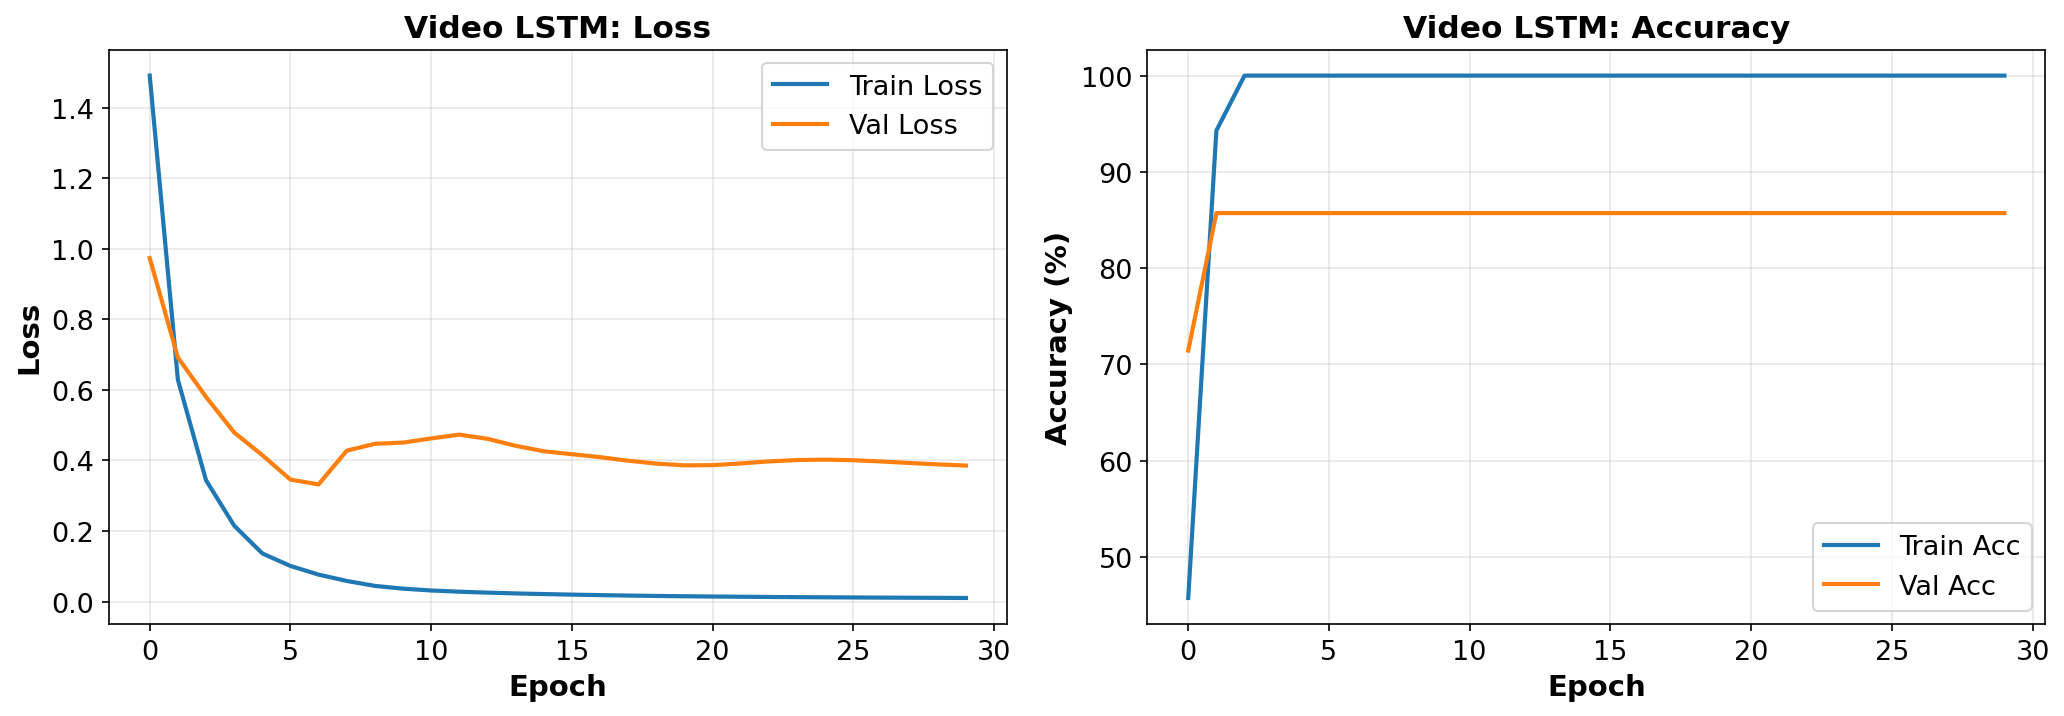

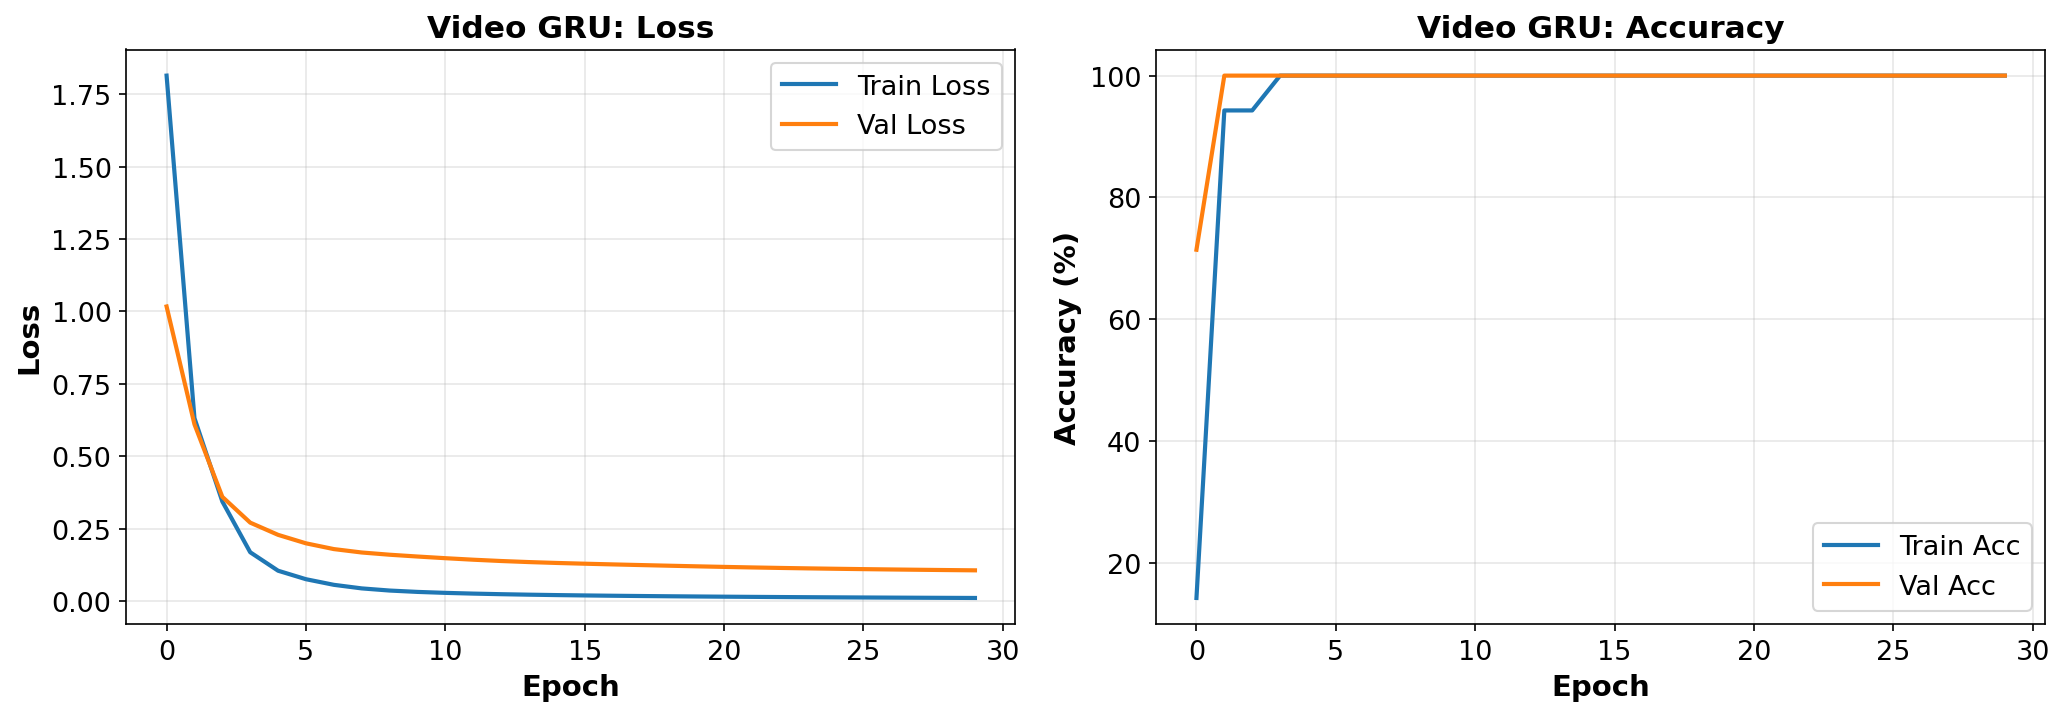

In [37]:
for layer_type in ['LSTM', 'GRU']:
    h = video_histories[layer_type].history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(h['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(h['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Video {layer_type}: Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(np.array(h['accuracy'])*100, label='Train Acc', linewidth=2)
    axes[1].plot(np.array(h['val_accuracy'])*100, label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'Video {layer_type}: Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'plot8_video_{layer_type.lower()}_curves.png'), bbox_inches='tight')
    plt.show()


### Plot 9: Video Confusion Matrix

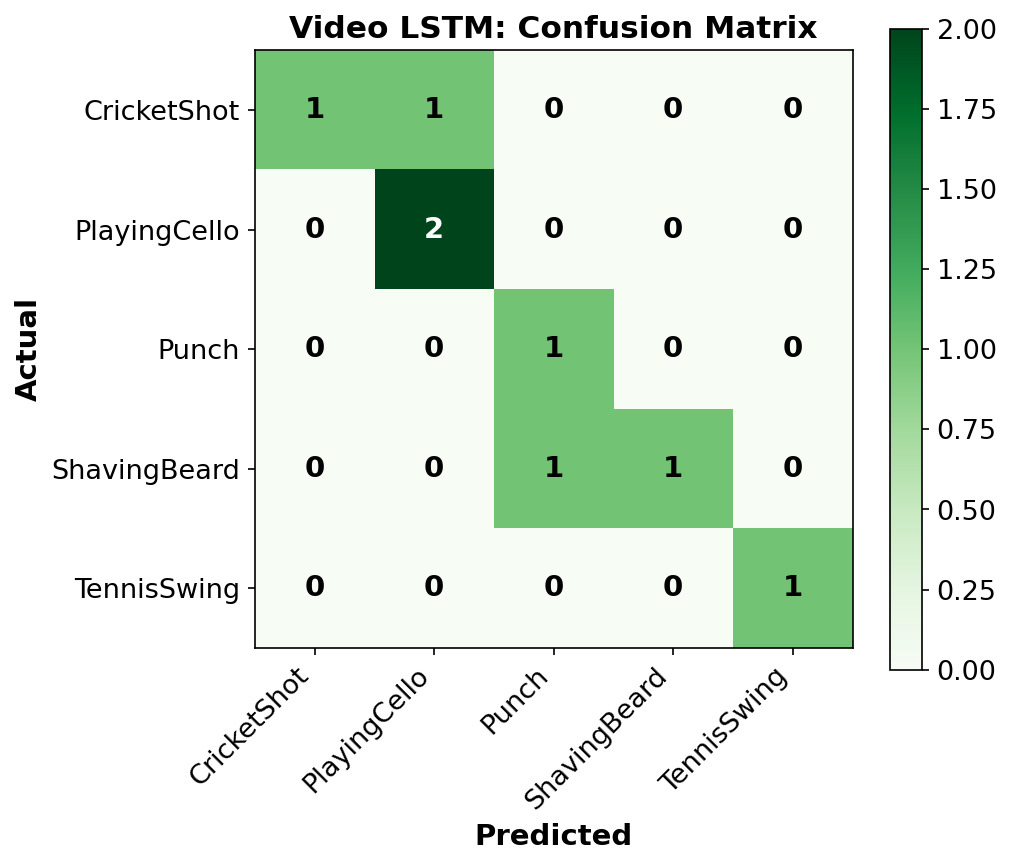

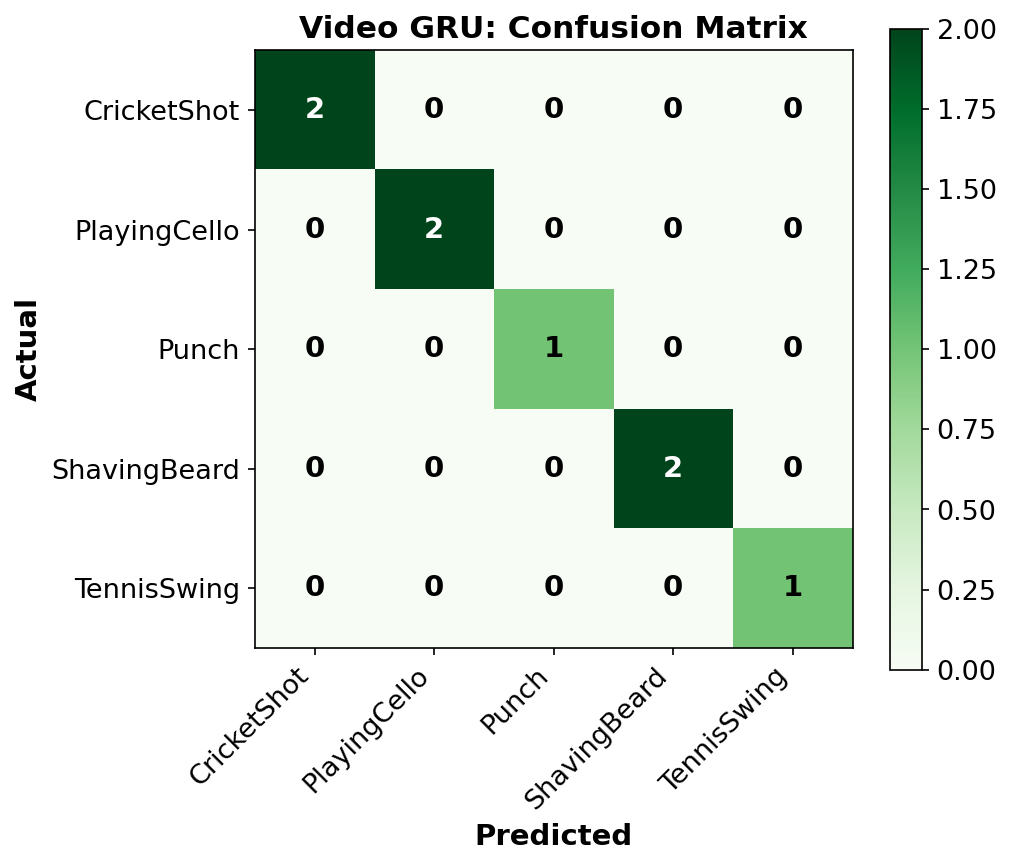

     accuracy  precision recall     f1  params train_time
LSTM     75.0  83.333333   80.0   76.0  168229   6.001736
GRU     100.0      100.0  100.0  100.0  126309   5.228896


In [38]:
for layer_type in ['LSTM', 'GRU']:
    cm = confusion_matrix(yv_test, video_results[layer_type]['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Greens')
    ax.set_xticks(range(len(SELECTED_CLASSES))); ax.set_xticklabels(SELECTED_CLASSES, rotation=45, ha='right')
    ax.set_yticks(range(len(SELECTED_CLASSES))); ax.set_yticklabels(SELECTED_CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Video {layer_type}: Confusion Matrix')
    for i in range(len(SELECTED_CLASSES)):
        for j in range(len(SELECTED_CLASSES)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontweight='bold')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'plot9_video_{layer_type.lower()}_confusion.png'), bbox_inches='tight')
    plt.show()

print(pd.DataFrame(video_results).T[['accuracy', 'precision', 'recall', 'f1', 'params', 'train_time']])


**Inference (Video CNN+LSTM/GRU):**
- Role of CNN: [Fill in -- MobileNetV2 extracts spatial features per frame (objects, pose, scene context) without needing to be trained on this small video set, since it's frozen and pretrained on ImageNet.]
- Role of recurrent model: [Fill in -- LSTM/GRU models how those per-frame spatial features change across the 10 sampled frames, capturing motion/temporal pattern rather than a single static pose.]
- [Fill in after running: compare LSTM vs GRU accuracy/F1 on this small video set -- note that 50 total videos is a very small sample, so results may be noisy; this is expected and worth stating in the report.]


In [39]:
zip_plots('exp6_checkpoint3_video_plots.zip')
print("Checkpoint 3 complete: video understanding pipeline.")


Plots zipped to: /kaggle/working/exp6/exp6_checkpoint3_video_plots.zip
Checkpoint 3 complete: video understanding pipeline.


---
# 22–24. Sequence-to-Sequence Learning -- Synthetic Reversal Task

⏱ **Estimated time: ~5 min**


In [40]:
SEQ_LEN_S2S = 4
VOCAB_MIN, VOCAB_MAX = 1, 9
N_SAMPLES_S2S = 5000

rng_s2s = np.random.RandomState(SEED)

def generate_reversal_data(n_samples, seq_len, vocab_min, vocab_max, rng):
    X = rng.randint(vocab_min, vocab_max + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1].copy()
    return X, Y

X_seq, Y_seq = generate_reversal_data(N_SAMPLES_S2S, SEQ_LEN_S2S, VOCAB_MIN, VOCAB_MAX, rng_s2s)
print("Example:", X_seq[0], "->", Y_seq[0])
print("Full data shape:", X_seq.shape, Y_seq.shape)


Example: [7 6 6 1] -> [1 6 6 7]
Full data shape: (5000, 4) (5000, 4)


In [41]:
VOCAB_SIZE = VOCAB_MAX + 1

def to_onehot(seqs, vocab_size):
    return keras.utils.to_categorical(seqs, num_classes=vocab_size)

X_s2s_oh = to_onehot(X_seq, VOCAB_SIZE)
Y_s2s_oh = to_onehot(Y_seq, VOCAB_SIZE)

decoder_input = np.zeros_like(Y_seq)
decoder_input[:, 1:] = Y_seq[:, :-1]
decoder_input_oh = to_onehot(decoder_input, VOCAB_SIZE)

idx_all = np.arange(N_SAMPLES_S2S)
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

Xtr_enc, Xtr_dec, Ytr = X_s2s_oh[idx_train], decoder_input_oh[idx_train], Y_seq[idx_train]
Xv_enc, Xv_dec, Yv = X_s2s_oh[idx_val], decoder_input_oh[idx_val], Y_seq[idx_val]
Xte_enc, Xte_dec, Yte = X_s2s_oh[idx_test], decoder_input_oh[idx_test], Y_seq[idx_test]

print("Train:", Xtr_enc.shape, " Val:", Xv_enc.shape, " Test:", Xte_enc.shape)


Train: (3500, 4, 10)  Val: (750, 4, 10)  Test: (750, 4, 10)


In [42]:
LATENT_DIM = 32
tf.random.set_seed(SEED)

encoder_inputs = layers.Input(shape=(SEQ_LEN_S2S, VOCAB_SIZE))
encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = layers.Input(shape=(SEQ_LEN_S2S, VOCAB_SIZE))
decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
seq2seq_model.summary()


Model: "functional_81"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_23      │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ [(None, 32),      │      5,504 │ input_layer_22[0… │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ [(None, 4, 32),   │      5,504 │ input_layer_23[0… │
│                     │ (None, 32),       │            │ lstm_9[0][1],     │
│                     │ (None, 32)]       │            │ lstm_9[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 4, 10)     │        330 │ lstm_10[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,338 (44.29 KB)

 Trainable params: 11,338 (44.29 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
t0 = time.time()
s2s_history = seq2seq_model.fit(
    [Xtr_enc, Xtr_dec], Ytr,
    validation_data=([Xv_enc, Xv_dec], Yv),
    epochs=50, batch_size=64, verbose=1)
s2s_time = time.time() - t0
print(f"Seq2seq training time: {s2s_time:.1f}s")


Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1768 - loss: 2.2542 - val_accuracy: 0.2527 - val_loss: 2.1782
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3039 - loss: 1.9796 - val_accuracy: 0.3510 - val_loss: 1.7507
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3966 - loss: 1.5782 - val_accuracy: 0.4277 - val_loss: 1.4366
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4709 - loss: 1.3145 - val_accuracy: 0.5090 - val_loss: 1.2084
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5851 - loss: 1.0862 - val_accuracy: 0.6590 - val_loss: 0.9779
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7365 - loss: 0.8592 - val_accuracy: 0.8050 - val_loss: 0.7561
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8561 - loss: 0.6549 - val_accuracy: 0.8997 - val_loss: 0.5683
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9209 - loss: 0.4924 - val_accuracy: 0.9480 - val_loss

In [44]:
def decode_sequence(encoder_input_seq, seq_len=SEQ_LEN_S2S, vocab_size=VOCAB_SIZE):
    enc_out, h, c = encoder_lstm(encoder_input_seq[np.newaxis, ...])
    target_seq = np.zeros((1, 1, vocab_size))
    target_seq[0, 0, 0] = 1.0

    decoded = []
    for _ in range(seq_len):
        output, h, c = decoder_lstm(target_seq, initial_state=[h, c])
        probs = decoder_dense(output)
        next_token = np.argmax(probs[0, 0, :].numpy())
        decoded.append(next_token)
        target_seq = np.zeros((1, 1, vocab_size))
        target_seq[0, 0, next_token] = 1.0
    return np.array(decoded)

test_predictions = []
for i in range(len(Xte_enc)):
    pred = decode_sequence(Xte_enc[i])
    test_predictions.append(pred)
test_predictions = np.array(test_predictions)

token_acc = (test_predictions == Yte).mean() * 100
seq_acc = (test_predictions == Yte).all(axis=1).mean() * 100

print(f"Token Accuracy   : {token_acc:.2f}%")
print(f"Sequence Accuracy: {seq_acc:.2f}%")


Token Accuracy   : 100.00%
Sequence Accuracy: 100.00%


In [45]:
print(f"{'Input':<20}{'Predicted Output':<20}{'Actual Output':<20}")
for i in range(5):
    inp = X_seq[idx_test[i]]
    pred = test_predictions[i]
    actual = Yte[i]
    print(f"{str(list(inp)):<20}{str(list(pred)):<20}{str(list(actual)):<20}")


Input               Predicted Output    Actual Output       
[np.int64(8), np.int64(2), np.int64(6), np.int64(4)][np.int64(4), np.int64(6), np.int64(2), np.int64(8)][np.int64(4), np.int64(6), np.int64(2), np.int64(8)]
[np.int64(6), np.int64(2), np.int64(4), np.int64(3)][np.int64(3), np.int64(4), np.int64(2), np.int64(6)][np.int64(3), np.int64(4), np.int64(2), np.int64(6)]
[np.int64(1), np.int64(7), np.int64(6), np.int64(1)][np.int64(1), np.int64(6), np.int64(7), np.int64(1)][np.int64(1), np.int64(6), np.int64(7), np.int64(1)]
[np.int64(7), np.int64(3), np.int64(7), np.int64(4)][np.int64(4), np.int64(7), np.int64(3), np.int64(7)][np.int64(4), np.int64(7), np.int64(3), np.int64(7)]
[np.int64(7), np.int64(1), np.int64(1), np.int64(8)][np.int64(8), np.int64(1), np.int64(1), np.int64(7)][np.int64(8), np.int64(1), np.int64(1), np.int64(7)]


### Seq2seq Training/Validation Curves

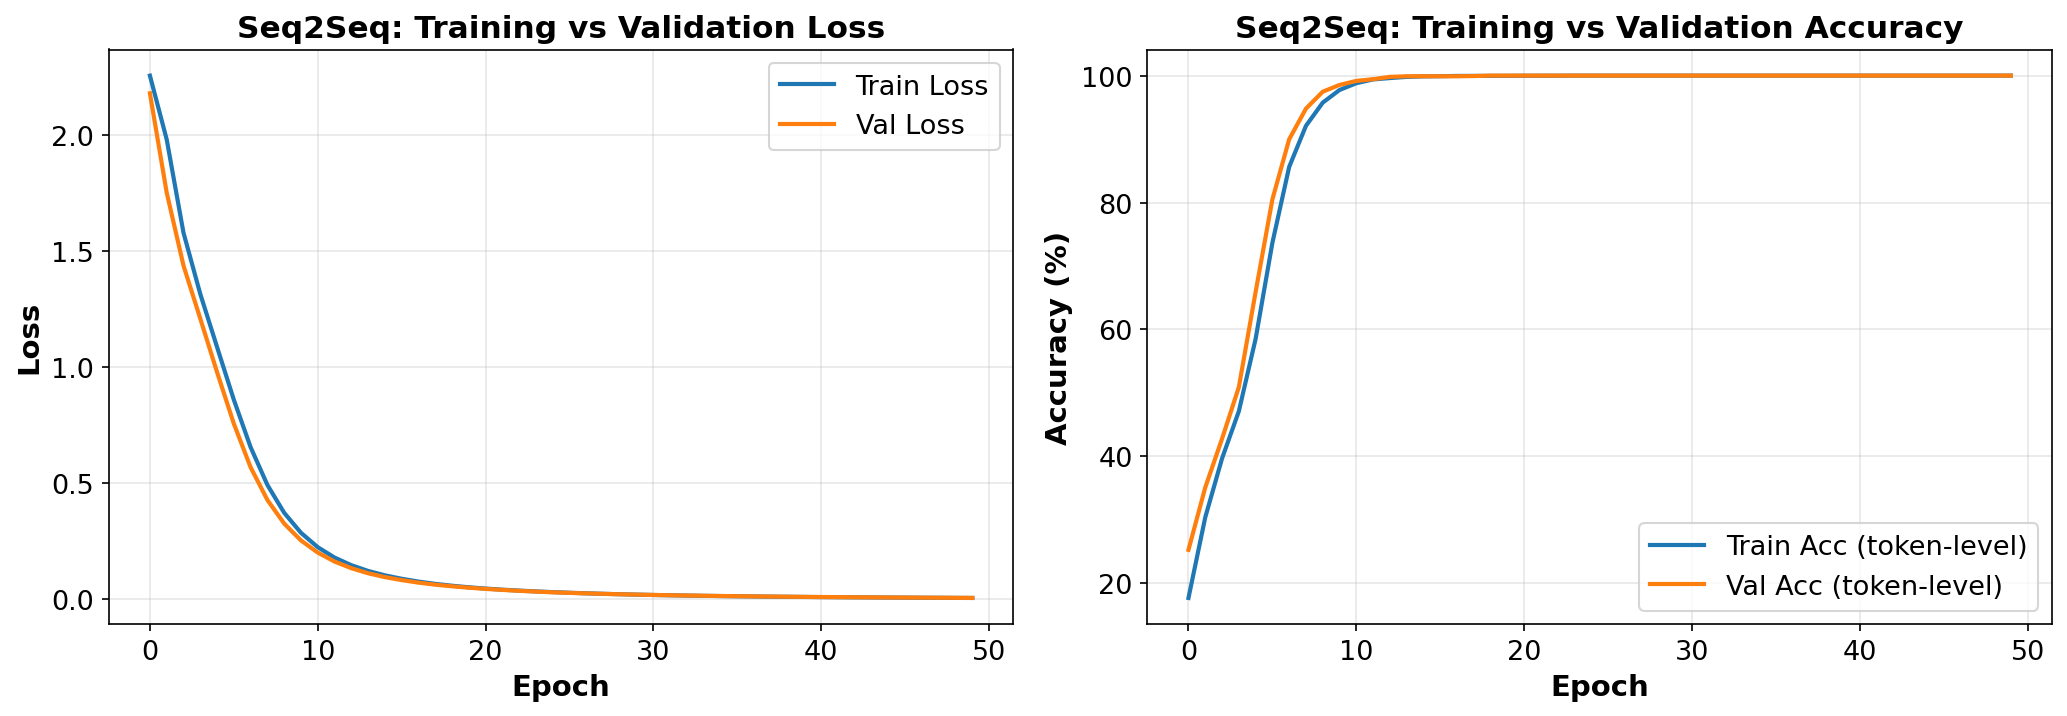

In [46]:
h = s2s_history.history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['loss'], label='Train Loss', linewidth=2)
axes[0].plot(h['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Seq2Seq: Training vs Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(np.array(h['accuracy'])*100, label='Train Acc (token-level)', linewidth=2)
axes[1].plot(np.array(h['val_accuracy'])*100, label='Val Acc (token-level)', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Seq2Seq: Training vs Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'plot10_seq2seq_curves.png'), bbox_inches='tight')
plt.show()

mark_block_done('seq2seq')


**Required inference (token accuracy vs sequence accuracy):**
[Fill in after running: sequence accuracy is typically much lower than token accuracy because a sequence only counts as correct if every token matches -- e.g. with 4 tokens each at 95% individual accuracy, the probability all 4 are simultaneously correct is roughly 0.95^4 = 81%, and this compounds worse as sequence length grows. Confirm this pattern holds in your actual numbers above.]


---
# 25. Consolidated Results

⏱ **Estimated time: <1 min**


In [47]:
consolidated = pd.DataFrame([
    {'Model': 'RNN', 'Accuracy': results_rnn['accuracy'], 'Precision': results_rnn['precision'],
     'Recall': results_rnn['recall'], 'F1': results_rnn['f1'], 'Parameters': results_rnn['params']},
    {'Model': 'LSTM', 'Accuracy': results_lstm['accuracy'], 'Precision': results_lstm['precision'],
     'Recall': results_lstm['recall'], 'F1': results_lstm['f1'], 'Parameters': results_lstm['params']},
    {'Model': 'GRU', 'Accuracy': results_gru['accuracy'], 'Precision': results_gru['precision'],
     'Recall': results_gru['recall'], 'F1': results_gru['f1'], 'Parameters': results_gru['params']},
    {'Model': 'CNN-LSTM (video)', 'Accuracy': video_results['LSTM']['accuracy'], 'Precision': video_results['LSTM']['precision'],
     'Recall': video_results['LSTM']['recall'], 'F1': video_results['LSTM']['f1'], 'Parameters': video_results['LSTM']['params']},
    {'Model': 'CNN-GRU (video)', 'Accuracy': video_results['GRU']['accuracy'], 'Precision': video_results['GRU']['precision'],
     'Recall': video_results['GRU']['recall'], 'F1': video_results['GRU']['f1'], 'Parameters': video_results['GRU']['params']},
])
print("HAR + Video Consolidated Results:")
print(consolidated)

seq2seq_summary = pd.DataFrame([{
    'Task': 'Seq2Seq Reversal', 'Token Accuracy': token_acc, 'Sequence Accuracy': seq_acc,
    'Final Train Loss': h['loss'][-1], 'Final Val Loss': h['val_loss'][-1]
}])
print("\nSeq2Seq Results:")
print(seq2seq_summary)

consolidated.to_csv(os.path.join(BASE_DIR, 'consolidated_results.csv'), index=False)
seq2seq_summary.to_csv(os.path.join(BASE_DIR, 'seq2seq_results.csv'), index=False)


HAR + Video Consolidated Results:
              Model    Accuracy   Precision      Recall          F1  \
0               RNN   75.000000   75.700727   75.000000   74.965660   
1              LSTM   93.055556   93.149680   93.055556   93.022443   
2               GRU   92.777778   92.788901   92.777778   92.775925   
3  CNN-LSTM (video)   75.000000   83.333333   80.000000   76.000000   
4   CNN-GRU (video)  100.000000  100.000000  100.000000  100.000000   

   Parameters  
0        1974  
1        6006  
2        4758  
3      168229  
4      126309  

Seq2Seq Results:
               Task  Token Accuracy  Sequence Accuracy  Final Train Loss  \
0  Seq2Seq Reversal           100.0              100.0          0.005994   

   Final Val Loss  
0        0.006318  


---
## Final -- Save Everything

Zips all plots and result tables from the complete run. On Kaggle, anything saved under `/kaggle/working/` is automatically downloadable from this notebook's **Output** tab (right sidebar → Output, after Save Version / commit) — no explicit download call needed.


In [48]:
final_zip = zip_plots('exp6_ALL_plots.zip')

print(f"Plots zip saved to: {final_zip}")
print(f"Results CSVs saved to: {os.path.join(BASE_DIR, 'consolidated_results.csv')}")
print(f"                       {os.path.join(BASE_DIR, 'seq2seq_results.csv')}")
print()
print("To download: click 'Save Version' (top right) to commit this run, then open the")
print("Output tab in the right sidebar -- all files under /kaggle/working/exp6 will be listed there.")
print()
print("All done. Review the inference placeholders marked '[Fill in after running]' throughout")
print("this notebook and fill them in with your actual observations before writing the report.")


Plots zipped to: /kaggle/working/exp6/exp6_ALL_plots.zip
Plots zip saved to: /kaggle/working/exp6/exp6_ALL_plots.zip
Results CSVs saved to: /kaggle/working/exp6/consolidated_results.csv
                       /kaggle/working/exp6/seq2seq_results.csv

To download: click 'Save Version' (top right) to commit this run, then open the
Output tab in the right sidebar -- all files under /kaggle/working/exp6 will be listed there.

All done. Review the inference placeholders marked '[Fill in after running]' throughout
this notebook and fill them in with your actual observations before writing the report.
